In [79]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

## 1. Evolutionary game theory (EGT) background

### Baseline game with no environmental feedback

$$M = \begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{x_2} = x_2(1-x_2)(-(\alpha+\beta)x_2+\alpha)
\end{eqnarray}

### Stability diagram in the payoff-parameter space ($\alpha, \beta$)

In [2]:
# phase diagram
def classify(alpha, beta):
    """Output:
       0 -> strategy 1 dominates (x=0 stable)
       1 -> strategy 2 dominates (x=1 stable)
       2 -> coexistence (interior stable)
       3 -> coordination/bistability (0 and 1 stable)
      -1 -> on axes (alpha=0 or beta=0)
    """
    if alpha < 0 and beta > 0:
        return 0
    if alpha > 0 and beta < 0:
        return 1
    if alpha > 0 and beta > 0:
        return 2
    if alpha < 0 and beta < 0:
        return 3
    return -1

A = np.linspace(-2, 2, 401)
B = np.linspace(-2, 2, 401)
AA, BB = np.meshgrid(A, B)
Z = np.zeros_like(AA, dtype=float)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        Z[i, j] = classify(AA[i, j], BB[i, j])

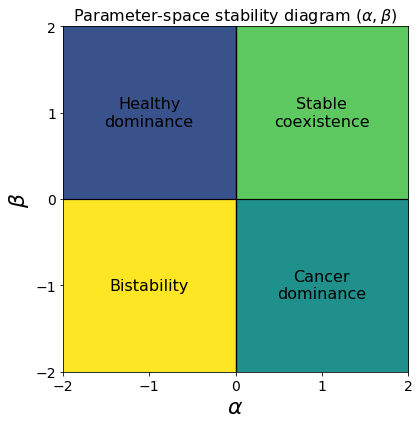

In [11]:
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(Z,origin='lower', extent=[A.min(), A.max(), B.min(), B.max()], aspect='equal')
ax.axhline(0, linewidth=1.2, color='black')
ax.axvline(0, linewidth=1.4, color='black')
ax.set(xticks=np.arange(-2,3),
       yticks=np.arange(-2,3),
       #xlabel=r'$\alpha$',
       #ylabel=r'$\beta$',
       #title=r'Phase diagram $(\alpha,\beta)$'
      )
ax.set_title(r'Parameter-space stability diagram $(\alpha,\beta)$',fontsize=16)
ax.set_xlabel(r'$\alpha$', fontsize=22)
ax.set_ylabel(r'$\beta$', fontsize=22)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
# or both
#ax.tick_params(labelsize=18)

# text
ax.text(-1, 1, 'Healthy\ndominance', fontsize= 16, color='black', ha='center', va='center')
ax.text(1,1, 'Stable\ncoexistence', fontsize= 16, color='black', ha='center', va='center')
ax.text(-1, -1, 'Bistability', fontsize= 16, color='black', ha='center', va='center')
ax.text(1, -1, 'Cancer\ndominance', fontsize= 16, color='black', ha='center', va='center')

plt.tight_layout()
plt.savefig('phase_alpha_beta.png', dpi=300)
plt.show()

#### Examples params

In [13]:
def x_2(x2,alpha,beta,dt):
    return (x2*(1-x2)*(-(alpha+beta)*x2+alpha))*dt + x2

$\alpha<0, \beta>0$

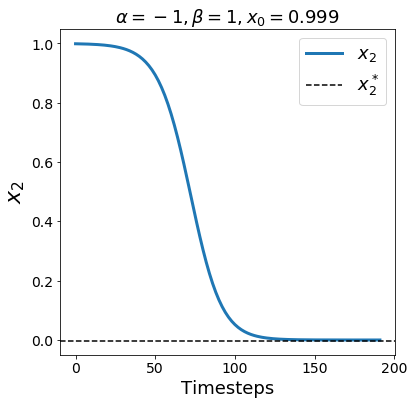

In [14]:
alpha = -1
beta = 1
dt = 0.1
x20 = 0.999

xs = [x20]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
ax.plot(xs,linewidth=3, label=r'$x_2$')
ax.axhline(-0.005,color='black', linestyle='--', label=r'$x_2^*$')

ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_0={x20}$', fontsize=18)
ax.legend(fontsize=18)

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'Figures/2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha>0, \beta<0$

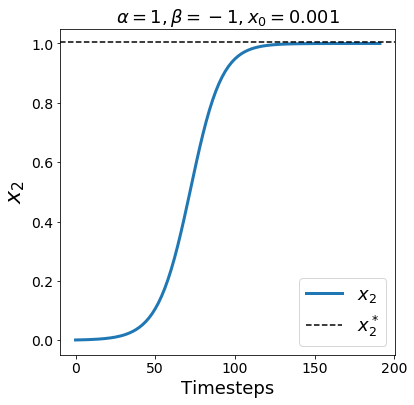

In [15]:
alpha = 1
beta = -1
dt = 0.1
x20 = 0.001

xs = [x20]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
ax.plot(xs,linewidth=3, label=r'$x_2$')
ax.axhline(1.005,color='black', linestyle='--', label=r'$x_2^*$')

ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_0={x20}$', fontsize=18)
ax.legend(fontsize=18)

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'Figures/2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha>0, \beta>0$

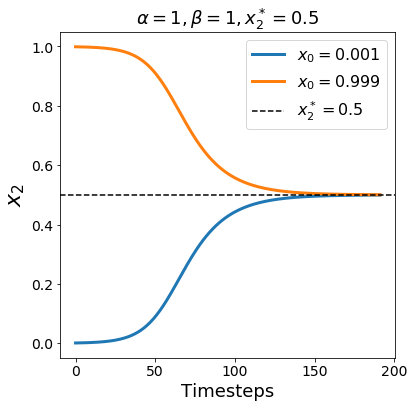

In [16]:
alpha = 1
beta = 1
dt = 0.1
xast = alpha/(alpha+beta)
x20_1 = 0.001
x20_2 = 0.999

xs1 = [x20_1]
xs2 = [x20_2]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs1.append(x_2(xs1[-1],alpha,beta,dt))
    xs2.append(x_2(xs2[-1],alpha,beta,dt))
    
ax.plot(xs1,linewidth=3,label=r'$x_0=0.001$')
ax.plot(xs2,linewidth=3,label=r'$x_0=0.999$')
ax.axhline((xs1[-1]+xs2[-2])/2,color='black', linestyle='--', label=rf'$x_2^*={xast}$')

ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_2^*=0.5$', fontsize=18)
ax.legend(fontsize=16)

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'Figures/2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha<0, \beta<0$

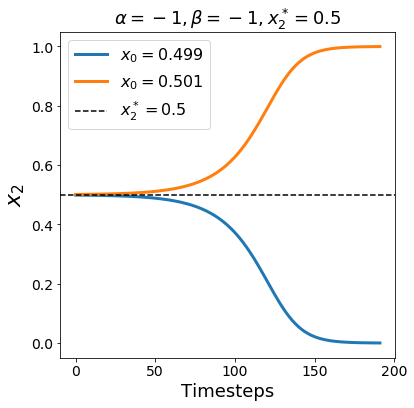

In [17]:
alpha = -1
beta = -1
dt = 0.1

xast = alpha/(alpha+beta)
x20_1 = alpha/(alpha+beta)-0.001
x20_2 = alpha/(alpha+beta)+0.001

xs1 = [x20_1]
xs2 = [x20_2]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs1.append(x_2(xs1[-1],alpha,beta,dt))
    xs2.append(x_2(xs2[-1],alpha,beta,dt))
    
ax.plot(xs1,linewidth=3,label=rf'$x_0={x20_1:.3f}$')
ax.plot(xs2,linewidth=3,label=rf'$x_0={x20_2:.3f}$')
ax.axhline((x20_1+x20_2)/2,color='black', linestyle='--', label=rf'$x_2^*={xast}$')

ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_2^*={alpha/(alpha+beta):.1f}$', fontsize=18)
ax.legend(fontsize=16)

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'Figures/2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

## 2. Two-players game with environmental feedback

\begin{equation}
    \begin{aligned}
        M(n) &= (1-f(n)) M_h + f(n)M_s \\
        f(n) &= \frac{n}{n+k} \\
        \dot{x_2} &= x_2(1-x_2)(-(\alpha(n)+\beta(n))+\alpha(n)) \\
        \dot{n} &= \epsilon x_2 - \mu n
    \end{aligned}
\end{equation}

In [152]:
def f(k,n):
    return n / (n+k)

def x(x,alphan,betan,dt):
    return (x*(1-x)*(-(alphan+betan)*x+alphan))*dt + x

def n(n,x,eps,mu,dt):
    return (eps*x - mu*n)*dt + n

def Ms_func(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mn(f_n,Mh,Ms):
    return (1-f_n)*Mh + f_n*Ms

In [153]:
def Mh_func(alpha,beta):
    return np.array([[0, beta],
                     [-alpha, 0]])

### Hostile environment

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha\frac{(n-k)}{n+k} & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \frac{n-k}{n+k}\right) \bigl(\beta x_2 + \alpha(1-x_2) \bigr)
\end{equation}

$\alpha=0.5, \beta=0.6, \epsilon=0.16, \mu=0.02, k=0.1$

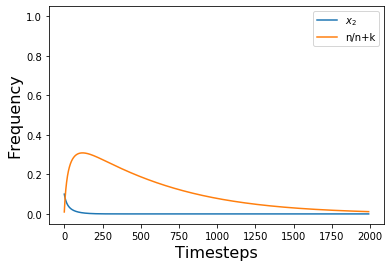

In [141]:
alpha = 0.5
beta = 0.6
eps = 0.16
mu = 0.02
k = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 200.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh, Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

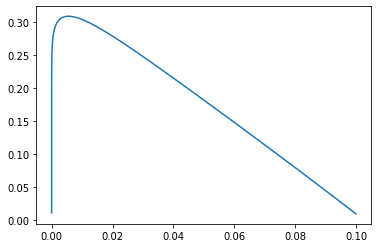

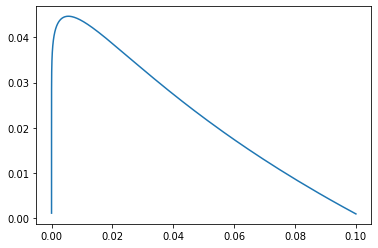

In [142]:
plt.plot(xs, f(k,np.array(ns)))
plt.show()

plt.plot(xs, ns)
plt.show()

$\alpha=0.5, \beta=0.6, \epsilon=0.23, \mu=0.02, k=0.1$

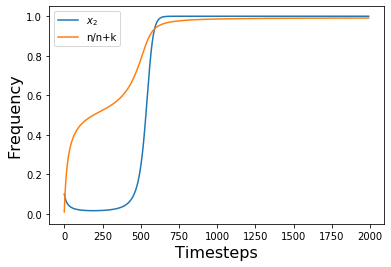

In [154]:
alpha = 0.5
beta = 0.6
eps = 0.23
mu = 0.02
k = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 200.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

In [144]:
## fixed points (x, n)
# (0, 0)
# (1, rho)
# (mu*k/eps=1/rho_hat, k)

In [177]:
# dynamics
def make_rhs_hostile(alpha, beta, epsilon, mu, k):
    def dxdt(t, x, n):
        return x * (1 - x) * (n - k) / (n + k) * (beta * x + alpha * (1 - x))
    
    def dndt(t, x, n):
        return epsilon * x - mu * n
    
    def f(t, y):
        x, n = y
        return [dxdt(t, x, n), dndt(t, x, n)]
    
    return f

In [178]:
# params
alpha = 1.0   # >0
beta  = 1.0   # >0
k     = 1.0   # tolerance
epsilon = 0.5
mu      = 1.0

rho = epsilon / mu
print("rho =", rho, "(should be < k for hostile, sub-threshold regime)")

rho = 0.5 (should be < k for hostile, sub-threshold regime)


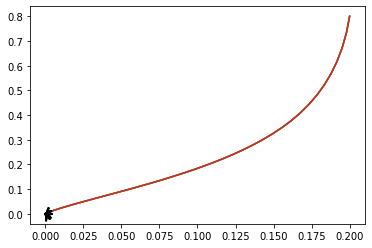

In [207]:
# trajectories
# a few initial conditions in the biological region
initial_conditions = [
    (0.1, 0.001),
    (0.5, 0.2),
    (0.8, 0.1),
    (0.2, 0.8),
]

t_span = (0.0, 50.0)
t_eval = np.linspace(t_span[0], t_span[1], 500)

for x0, n0 in initial_conditions:
    f = make_rhs_hostile(alpha, beta, epsilon, mu, k)
    sol = solve_ivp(f, t_span, [x0, n0], t_eval=t_eval, dense_output=False)
    #plt.plot(sol.y[0], sol.y[1])
    plt.plot(x_traj, n_traj)
    
    # add an arrow along the trajectory
    indices = [len(x_traj)//4, len(x_traj)//2, 3*len(x_traj)//4]
    for idx in indices:
        if idx < len(x_traj) - 1:
            x_start = x_traj[idx]
            n_start = n_traj[idx]
            x_end   = x_traj[idx + 1]
            n_end   = n_traj[idx + 1]

            plt.annotate(
                "",
                xy=(x_end, n_end), xytext=(x_start, n_start),
                arrowprops=dict(arrowstyle="->", lw=2)
            )

    

In [208]:
indices

[125, 250, 375]

In [218]:
def add_arrows_to_line2D(line, n_arrows=3, arrowstyle='->', lw=1):
    """
    Add `n_arrows` arrows along a 2D line (Line2D object from plt.plot).
    Arrows are approximately equally spaced by arc length.
    """
    ax = line.axes
    x = line.get_xdata()
    y = line.get_ydata()
    color = line.get_color()

    N = len(x)
    if N < 2:
        return

    # cumulative arc length along the curve
    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx**2 + dy**2)
    s = np.concatenate(([0.0], np.cumsum(ds)))

    if s[-1] == 0:
        return  # completely flat / single point

    s_norm = s / s[-1]  # 0 -> 1 along the curve

    # where (in [0,1]) to place arrows (avoid very start and very end)
    targets = np.linspace(0.2, 0.8, n_arrows)

    for t in targets:
        # index where cumulative length first exceeds target
        idx = np.searchsorted(s_norm, t)
        if idx <= 0 or idx >= N:
            continue

        # arrow from point idx-1 to idx (direction of motion)
        x_start, y_start = x[idx-1], y[idx-1]
        x_end,   y_end   = x[idx],   y[idx]

        ax.annotate(
            "",
            xy=(x_end, y_end), xytext=(x_start, y_start),
            arrowprops=dict(
                arrowstyle=arrowstyle,
                color=color,
                lw=lw,
                shrinkA=0,
                shrinkB=0,
            ),
        )


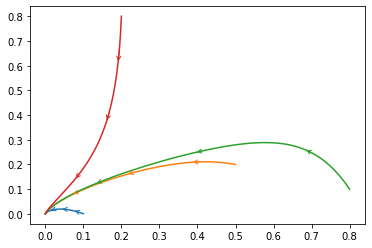

In [215]:
# trajectories
initial_conditions = [
    (0.1, 0.001),
    (0.5, 0.2),
    (0.8, 0.1),
    (0.2, 0.8),
]

t_span = (0.0, 50.0)
t_eval = np.linspace(t_span[0], t_span[1], 500)

for x0, n0 in initial_conditions:
    f = make_rhs_hostile(alpha, beta, epsilon, mu, k)
    sol = solve_ivp(f, t_span, [x0, n0], t_eval=t_eval)
    x_traj = sol.y[0]#, :]
    n_traj = sol.y[1]#, :]

    # plot trajectory and get Line2D handle
    (line,) = plt.plot(x_traj, n_traj)

    # add arrows along this trajectory
    add_arrows_to_line2D(line, n_arrows=3)


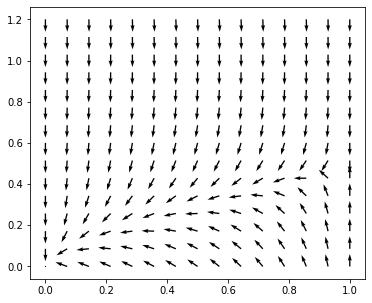

In [185]:
# phase portrait, vector field
# state-space grid
x_vals = np.linspace(0.0, 1.0, 15)
n_max  = max(rho * 1.2, k * 1.2)
n_vals = np.linspace(0.0, n_max, 15)

X, N = np.meshgrid(x_vals, n_vals)

# compute vector field
f = make_rhs_hostile(alpha, beta, epsilon, mu, k)
U, V = f(0.0, (X, N))

# normalize arrows
speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

# plot vector field
plt.figure(figsize=(6, 5))
plt.quiver(X, N, U_norm, V_norm, angles="xy")

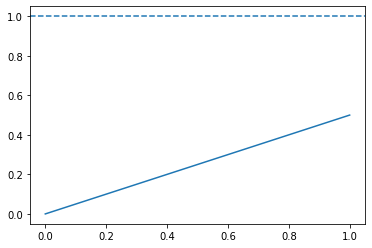

In [171]:
# nullclines
# n-nullcline: dn/dt = 0 -> n = rho * x
x_nc = np.linspace(0.0, 1.0, 200)
n_nc = rho * x_nc
plt.plot(x_nc, n_nc, label="n-nullcline (dn/dt = 0)")

# x-nullcline: dx/dt = 0 includes:
# x = 0, x = 1, and n = k (for interior x)
plt.axhline(k, linestyle="--", label="x-nullcline (n = k)")
# x=0 and x=1 are the boundaries of the domain, no extra line needed.

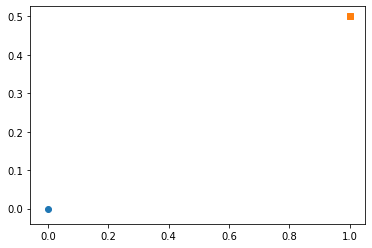

In [172]:
# equilibria
# (0, 0): always an equilibrium, stable for rho < k in hostile scenario
plt.scatter([0.0], [0.0], marker="o", label="Equilibrium (0, 0)")

# (1, rho): cancer boundary equilibrium (saddle here because rho < k)
plt.scatter([1.0], [rho], marker="s", label="Equilibrium (1, rho)")

# Threshold point (mu*k/epsilon, k) is outside x in [0,1] when rho < k,
# so we do not plot it here.

### $\rho<k$

rho = 0.5 (should be < k=1.0 for hostile, sub-threshold regime)


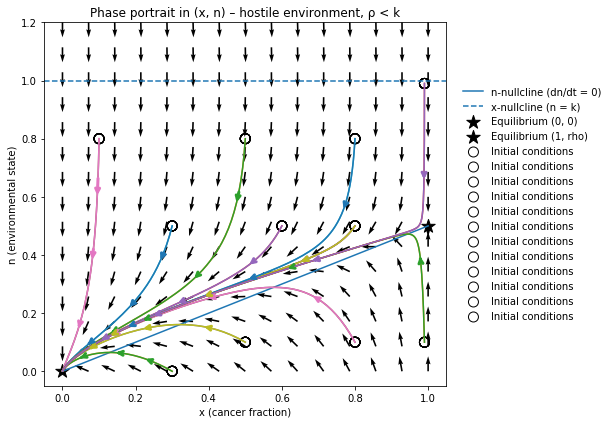

In [258]:
## parameters for hostile scenario
alpha = 1.0   # >0
beta  = 1.0   # >0
k     = 1.0   # tolerance
epsilon = 0.5
mu      = 1.0

rho = epsilon / mu  # environmental load
print("rho =", rho, f"(should be < k={k} for hostile, sub-threshold regime)")


## dynamics
def make_rhs_hostile(alpha, beta, epsilon, mu, k):
    def dxdt(t, x, n):
        return x * (1 - x) * (n - k) / (n + k) * (beta * x + alpha * (1 - x))
    
    def dndt(t, x, n):
        return epsilon * x - mu * n
    
    def f(t, y):
        x, n = y
        return [dxdt(t, x, n), dndt(t, x, n)]
    
    return f


## phase portrait, vector field
## state-space grid
x_vals = np.linspace(0.0, 1.0, 15)
n_max  = max(rho * 1.2, k * 1.2)
n_vals = np.linspace(0.0, n_max, 15)

X, N = np.meshgrid(x_vals, n_vals)

# compute vector field
f = make_rhs_hostile(alpha, beta, epsilon, mu, k)
U, V = f(0.0, (X, N))

# normalize arrows
speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

# plot vector field
fig, ax = plt.subplots(figsize=(8, 6))
#plt.figure(figsize=(8, 6))
#plt.quiver(X, N, U_norm, V_norm, angles="xy")
ax.quiver(X, N, U_norm, V_norm, angles="xy")

## nullclines
# n-nullcline: dn/dt = 0 -> n = rho * x
x_nc = np.linspace(0.0, 1.0, 200)
n_nc = rho * x_nc
ax.plot(x_nc, n_nc, label="n-nullcline (dn/dt = 0)")

# x-nullcline: dx/dt = 0 includes:
# x = 0, x = 1, and n = k (for interior x)
ax.axhline(k, linestyle="--", label="x-nullcline (n = k)")
# x=0 and x=1 are the boundaries of the domain, no extra line needed.


# equilibria
# (0, 0): always an equilibrium, stable for rho < k in hostile scenario
ax.scatter([0.0], [0.0], 
            marker="*", 
            s=200, 
            color='k', 
            label="Equilibrium (0, 0)"
           )

# (1, rho): cancer boundary equilibrium (saddle here because rho < k)
ax.scatter([1.0], 
            [rho], 
            marker="*", 
            s=200, 
            color='k', 
            label="Equilibrium (1, rho)"
           )

# Threshold point (mu*k/epsilon, k) is outside x in [0,1] when rho < k,
# so we do not plot it here.


# trajectories
# a few initial conditions in the biological region
"""
initial_conditions = [
    (0.2, 0.0),
    (0.5, 0.2),
    (0.99, 0.1),
    (0.2, 0.8),
]
"""
initial_conditions = [
    (0.3, 0.0),
    (0.8, 0.5),
    (0.1, 0.8),
    (0.5, 0.1),
    (0.3, 0.5),
    (0.5, 0.8),
    (0.6, 0.5),
    (0.8, 0.1),
    (0.8, 0.5),
    (0.8, 0.8),
    (0.99, 0.1),
    (0.99, 0.99)
]

t_span = (0.0, 50.0)
t_eval = np.linspace(t_span[0], t_span[1], 500)

for x0, n0 in initial_conditions:
    f = make_rhs_hostile(alpha, beta, epsilon, mu, k)
    sol = solve_ivp(f, t_span, [x0, n0], t_eval=t_eval, dense_output=False)
    #plt.plot(sol.y[0], sol.y[1])
    x_traj, n_traj = sol.y
    (line,) = ax.plot(x_traj, n_traj)

    # plot trajectory and get Line2D handle
    (line,) = ax.plot(x_traj, n_traj)
    # add arrows along this trajectory
    add_arrows_to_line2D(line, n_arrows=3, lw=3)
    
    # Plot initial condition markers on top
    x0_list = [ic[0] for ic in initial_conditions]
    n0_list = [ic[1] for ic in initial_conditions]

    ax.scatter(
        x0_list, n0_list,
        marker="o",
        s=100,
        edgecolor="k",
        facecolor="none",
        label="Initial conditions"
    )

## formatting
ax.set_xlabel("x (cancer fraction)")
ax.set_ylabel("n (environmental state)")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, n_max)
ax.set_title("Phase portrait in (x, n) – hostile environment, ρ < k")

# leave space on the right
fig.tight_layout(rect=[0, 0, 0.8, 1])
# legend outside
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.show()

### $\rho > k$

rho = 2.0 (should be > k for hostile, super-threshold regime)


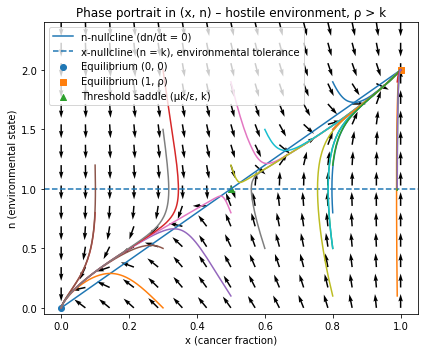

In [304]:
# -----------------------------
# Parameters for hostile scenario, ρ > k
# -----------------------------
alpha = 1.0   # >0
beta  = 1.0   # >0
k     = 1.0   # tolerance

epsilon = 2.0  # choose epsilon big so that rho > k
mu      = 1.0

rho = epsilon / mu  # environmental load
print("rho =", rho, "(should be > k for hostile, super-threshold regime)")

# -----------------------------
# Dynamics (same function factory as you defined)
# -----------------------------
def make_rhs_hostile(alpha, beta, epsilon, mu, k):
    def dxdt(t, x, n):
        # handle n = -k safely to avoid division by zero in practice
        return x * (1 - x) * (n - k) / (n + k) * (beta * x + alpha * (1 - x))
    
    def dndt(t, x, n):
        return epsilon * x - mu * n
    
    def f(t, y):
        x, n = y
        return [dxdt(t, x, n), dndt(t, x, n)]
    
    return f

f = make_rhs_hostile(alpha, beta, epsilon, mu, k)

# -----------------------------
# Phase portrait: vector field
# -----------------------------
x_vals = np.linspace(0.0, 1.0, 15)
n_max  = max(rho * 1.2, k * 1.2)
n_vals = np.linspace(0.0, n_max, 15)

X, N = np.meshgrid(x_vals, n_vals)

U, V = f(0.0, (X, N))

# normalize arrows
speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

plt.figure(figsize=(6, 5))
plt.quiver(X, N, U_norm, V_norm, angles="xy")

# -----------------------------
# Nullclines
# -----------------------------
# n-nullcline: dn/dt = 0 -> n = rho * x
x_nc = np.linspace(0.0, 1.0, 200)
n_nc = rho * x_nc
plt.plot(x_nc, n_nc, label="n-nullcline (dn/dt = 0)")

# x-nullcline: dx/dt = 0 includes x=0, x=1, and n = k (for interior x)
plt.axhline(k, linestyle="--", label="x-nullcline (n = k), environmental tolerance")
# x = 0 and x = 1 are just the boundaries of the domain

# -----------------------------
# Equilibria
# -----------------------------
# (0, 0): still a stable node mathematically, but its basin is small once ρ > k
plt.scatter([0.0], [0.0], marker="o", label="Equilibrium (0, 0)")

# (1, rho): cancer boundary equilibrium, now stable (cancer-dominated)
plt.scatter([1.0], [rho], marker="s", label="Equilibrium (1, ρ)")

# Threshold saddle (μ k / ε, k) – now lies in (0,1) for ρ > k
x_thresh = mu * k / epsilon
n_thresh = k
plt.scatter([x_thresh], [n_thresh], marker="^", label="Threshold saddle (μk/ε, k)")

# -----------------------------
# Sample trajectories to show basins
# -----------------------------
# Choose initial conditions on both sides of the saddle
"""
initial_conditions = [
    (0.1, 0.05),   # likely flows to (0,0)
    (0.2, 0.5),    # near the saddle region
    (0.6, 0.1),    # should go to (1, ρ)
    (0.8, 0.5),    # should go to (1, ρ)
]
"""
initial_conditions = [
    (0.3, 0.0),
    (0.8, 0.5),
    (0.1, 0.8),
    (0.5, 0.1),
    (0.3, 0.5),
    (0.5, 0.8),
    (0.6, 0.5),
    (0.8, 0.1),
    (0.8, 0.5),
    (0.8, 0.8),
    (0.99, 0.1),
    (0.99, 0.99),
    # reflect
    (0.3, 2.0),
    (0.8, 1.5),
    (0.1, 1.2),
    (0.5, 1.9),
    (0.3, 1.5),
    (0.5, 1.2),
    (0.6, 1.5),
    (0.8, 1.9),
    (0.8, 1.5),
    (0.8, 1.2),
    (0.99, 1.9),
    (0.99, 1.01)
]

t_span = (0.0, 50.0)
t_eval = np.linspace(t_span[0], t_span[1], 500)

for x0, n0 in initial_conditions:
    sol = solve_ivp(f, t_span, [x0, n0], t_eval=t_eval, dense_output=False)
    plt.plot(sol.y[0], sol.y[1])

# -----------------------------
# Formatting
# -----------------------------
plt.xlabel("x (cancer fraction)")
plt.ylabel("n (environmental state)")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, n_max)
plt.title("Phase portrait in (x, n) – hostile environment, ρ > k")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Basin boundaries, eigenvectors

In [268]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eig

# -----------------------------
# Parameters (hostile scenario, ρ > k)
# -----------------------------
alpha = 1.0   # > 0
beta  = 1.0   # > 0
k     = 1.0   # tolerance

epsilon = 2.0  # choose epsilon big so that rho > k
mu      = 1.0

rho = epsilon / mu  # environmental load
print("rho =", rho, "(should be > k)")

# Threshold saddle coordinates
x_saddle = mu * k / epsilon   # = k / rho
n_saddle = k
print("Saddle at (x, n) = ", x_saddle, n_saddle)


# -----------------------------
# Dynamics: hostile environment
# -----------------------------
def make_rhs_hostile(alpha, beta, epsilon, mu, k):
    def dxdt(t, x, n):
        # dx/dt = x(1-x)*(n-k)/(n+k)*(beta*x + alpha(1-x))
        return x * (1 - x) * (n - k) / (n + k) * (beta * x + alpha * (1 - x))

    def dndt(t, x, n):
        # dn/dt = epsilon * x - mu * n
        return epsilon * x - mu * n

    def f(t, y):
        x, n = y
        return [dxdt(t, x, n), dndt(t, x, n)]

    return f

f = make_rhs_hostile(alpha, beta, epsilon, mu, k)


rho = 2.0 (should be > k)
Saddle at (x, n) =  0.5 1.0


In [269]:
def integrate_trajectory(y0, t_span=(0.0, 50.0), t_points=500):
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = solve_ivp(f, t_span, y0, t_eval=t_eval, dense_output=False)
    return sol.t, sol.y  # t, [x(t), n(t)]

#### a. Zoomed phase portrait around the threshold saddle

This is a zoomed vector field + trajectories near ($\dot x, \dot n$)=($\mu k/\epsilon,k$) to visually show the saddle structure

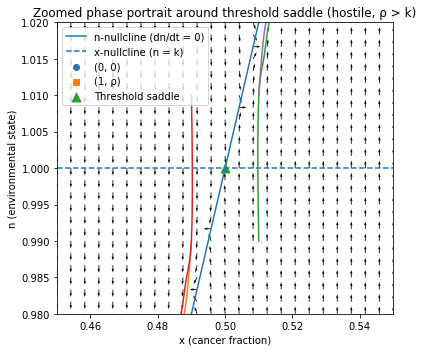

In [278]:
# -----------------------------
# Zoomed phase portrait around the saddle
# -----------------------------

# Zoom window around the saddle
dx = 0.05
dn = 0.02

x_min = max(0.0, x_saddle - dx)
x_max = min(1.0, x_saddle + dx)
n_min = max(0.0, n_saddle - dn)
n_max = n_saddle + dn

# Grid for vector field
x_vals = np.linspace(x_min, x_max, 25)
n_vals = np.linspace(n_min, n_max, 25)
X, N = np.meshgrid(x_vals, n_vals)

U, V = f(0.0, (X, N))

# Normalize arrows for nicer plotting
speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

plt.figure(figsize=(6, 5))
plt.quiver(X, N, U_norm, V_norm, angles="xy")

# Nullclines in the zoomed region
# n-nullcline: n = rho * x
x_nc = np.linspace(x_min, x_max, 200)
n_nc = rho * x_nc
plt.plot(x_nc, n_nc, label="n-nullcline (dn/dt = 0)")

# x-nullcline: includes n = k
plt.axhline(k, linestyle="--", label="x-nullcline (n = k)")

# Mark the equilibria: (0,0), (1,rho), and the threshold saddle
plt.scatter([0.0], [0.0], marker="o", label="(0, 0)")
plt.scatter([1.0], [rho], marker="s", label="(1, ρ)")
plt.scatter([x_saddle], [n_saddle], marker="^", s=80, label="Threshold saddle")

# Trajectories starting very close to the saddle, slightly on different sides
initial_conditions = [
    (x_saddle - 0.01, n_saddle - 0.01),
    (x_saddle + 0.01, n_saddle - 0.01),
    (x_saddle - 0.01, n_saddle + 0.01),
    (x_saddle + 0.01, n_saddle + 0.01),
]

t_span = (0.0, 50.0)

for x0, n0 in initial_conditions:
    t, y = integrate_trajectory([x0, n0], t_span=t_span, t_points=800)
    plt.plot(y[0], y[1])  # x(t) vs n(t)

plt.xlabel("x (cancer fraction)")
plt.ylabel("n (environmental state)")
plt.xlim(x_min, x_max)
plt.ylim(n_min, n_max)
plt.title("Zoomed phase portrait around threshold saddle (hostile, ρ > k)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


#### b. Local basin of attraction map around the saddle

Now we colour initial conditions in a small box around the saddle by which attractor they converge to. The boundary between colours is the basin boundary (the stable manifold, locally).

In [301]:
# -----------------------------
# Local basin-of-attraction map around the saddle
# -----------------------------

# Local grid around the saddle
dx_local = 0.15
dn_local = 0.15

x_min = max(0.0, x_saddle - dx_local)
x_max = min(1.0, x_saddle + dx_local)
n_min = max(0.0, n_saddle - dn_local)
n_max = n_saddle + dn_local

nx = 120
nn = 120
x_grid = np.linspace(x_min, x_max, nx)
n_grid = np.linspace(n_min, n_max, nn)

basin = np.zeros((nn, nx))  # 0 for healthy attractor, 1 for cancer attractor

t_span = (0.0, 80.0)

for i, n0 in enumerate(n_grid):
    for j, x0 in enumerate(x_grid):
        t, y = integrate_trajectory([x0, n0], t_span=t_span, t_points=600)
        x_final = y[0, -1]
        # classify attractor based on final x
        if x_final < 0.5:
            basin[i, j] = 0.0  # healthy basin
        else:
            basin[i, j] = 1.0  # cancer basin

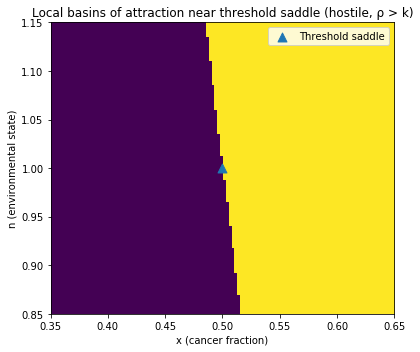

In [302]:
plt.figure(figsize=(6, 5))

# imshow: note origin='lower' to align axes with x,n coordinates
plt.imshow(
    basin,
    origin="lower",
    extent=[x_min, x_max, n_min, n_max],
    aspect="auto"
)

plt.scatter([x_saddle], [n_saddle], marker="^", s=80, label="Threshold saddle")

plt.xlabel("x (cancer fraction)")
plt.ylabel("n (environmental state)")
plt.title("Local basins of attraction near threshold saddle (hostile, ρ > k)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

Every point ($x_0, n_0$) in the small box is coloured according to its long-term fate:

- One colour = trajectories that end up in the healthy equilibrium.
- Another colour = trajectories that end up in the cancer equilibrium.
- The sharp boundary between the two colour regions is the basin boundary.
- The saddle lies exactly on this boundary.
- This plot makes the “threshold” idea extremely clear: the basin boundary is a critical curve – small perturbations across it flip the long-term outcome.

#### c. Environmental tolerance line n = k as payoff sign flip

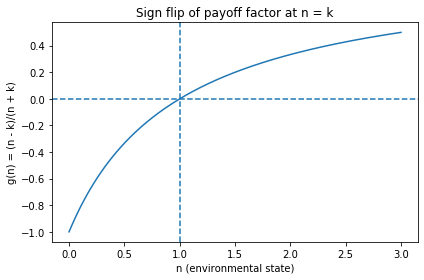

In [281]:
# Simple 1D plot of payoff factor g(n) = (n-k)/(n+k)
n_vals_line = np.linspace(0.0, 3.0 * k, 400)
g_vals = (n_vals_line - k) / (n_vals_line + k)

plt.figure()
plt.plot(n_vals_line, g_vals)
plt.axhline(0.0, linestyle="--")
plt.axvline(k, linestyle="--")
plt.xlabel("n (environmental state)")
plt.ylabel("g(n) = (n - k)/(n + k)")
plt.title("Sign flip of payoff factor at n = k")
plt.tight_layout()
plt.show()

When $n<k$, we have healthy-favoured payoffs, and when $n>k$, we have cancer-favoured payoffs. That is, once the secreted factor exceeds tolerance $k$, the interaction payoffs reverse sign and cancer gets the advantage.

#### d. Global basin boundary plot

Global basin-of-attraction map over a larger chunk of state space

In [294]:
# -----------------------------
# Global basin-of-attraction map
# -----------------------------

x_min, x_max = 0.0, 1.0
n_min, n_max = 0.0, max(rho * 1.2, k * 1.5)

nx = 120
nn = 120
x_grid = np.linspace(x_min, x_max, nx)
n_grid = np.linspace(n_min, n_max, nn)

basin_global = np.zeros((nn, nx))  # 0 for healthy, 1 for cancer

t_span = (0.0, 80.0)

for i, n0 in enumerate(n_grid):
    for j, x0 in enumerate(x_grid):
        t, y = integrate_trajectory([x0, n0], t_span=t_span, t_points=500)
        x_final = y[0, -1]
        if x_final < 0.5:
            basin_global[i, j] = 0.0
        else:
            basin_global[i, j] = 1.0

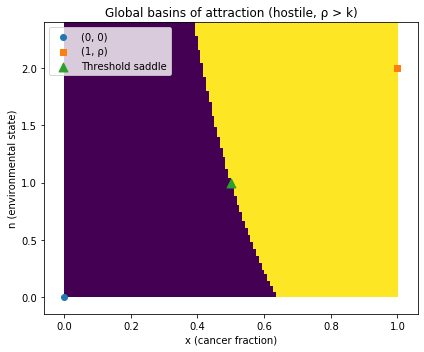

In [299]:
plt.figure(figsize=(6, 5))
plt.imshow(
    basin_global,
    origin="lower",
    extent=[x_min, x_max, n_min, n_max],
    aspect="auto"
)

# Mark equilibria
plt.scatter([0.0], [0.0], marker="o", label="(0, 0)")
plt.scatter([1.0], [rho], marker="s", label="(1, ρ)")
plt.scatter([x_saddle], [n_saddle], marker="^", s=80, label="Threshold saddle")

plt.xlabel("x (cancer fraction)")
plt.ylabel("n (environmental state)")
plt.title("Global basins of attraction (hostile, ρ > k)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

The state space is partitioned into two coloured regions:
- One basin → trajectories go to (0,0).
- Other basin → trajectories go to (1,ρ).
- The curved boundary between these regions is the basin boundary.
- The saddle lies on this boundary.

This is a global picture of the same threshold phenomenon: now we see how initial tumour load and environmental state together determine fate.

#### d. Stable and unstable manifolds via eigenvectors

Here we approximate the stable and unstable manifolds by using the local linearisation (Jacobian).

#### d.1 Numerical Jacobian at the saddle

In [287]:
# -----------------------------
# Numerical Jacobian at the saddle
# -----------------------------

def numerical_jacobian(f, x, n, h=1e-5):
    """
    Numerical Jacobian of the vector field f at (x, n).
    f: (t, [x, n]) -> [dx/dt, dn/dt]
    """
    # central differences
    # partial wrt x
    fx_plus  = np.array(f(0.0, [x + h, n]))
    fx_minus = np.array(f(0.0, [x - h, n]))
    dfdx = (fx_plus - fx_minus) / (2 * h)

    # partial wrt n
    fn_plus  = np.array(f(0.0, [x, n + h]))
    fn_minus = np.array(f(0.0, [x, n - h]))
    dfdn = (fn_plus - fn_minus) / (2 * h)

    # Jacobian matrix J = [[d(dx/dt)/dx, d(dx/dt)/dn], [d(dn/dt)/dx, d(dn/dt)/dn]]
    J = np.column_stack((dfdx, dfdn))
    return J

J = numerical_jacobian(f, x_saddle, n_saddle)
print("Jacobian at saddle:\n", J)

eigvals, eigvecs = eig(J)
print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)


Jacobian at saddle:
 [[ 0.     0.125]
 [ 2.    -1.   ]]
Eigenvalues: [ 0.20710678 -1.20710678]
Eigenvectors (columns):
 [[ 0.51673094 -0.1030026 ]
 [ 0.85614785  0.99468109]]


We see one eigenvalue with negative real part (stable), and one with positive real part (unstable). Now let’s extract the stable and unstable eigenvectors:

In [288]:
# Identify stable and unstable eigenvectors
idx_stable  = np.argmin(np.real(eigvals))   # most negative eigenvalue
idx_unst    = np.argmax(np.real(eigvals))   # most positive eigenvalue

v_stable    = np.real(eigvecs[:, idx_stable])
v_unstable  = np.real(eigvecs[:, idx_unst])

# Normalize for plotting
v_stable   /= np.linalg.norm(v_stable)
v_unstable /= np.linalg.norm(v_unstable)

print("Stable eigenvalue:", eigvals[idx_stable])
print("Stable eigenvector:", v_stable)
print("Unstable eigenvalue:", eigvals[idx_unst])
print("Unstable eigenvector:", v_unstable)

Stable eigenvalue: -1.2071067811916834
Stable eigenvector: [-0.1030026   0.99468109]
Unstable eigenvalue: 0.2071067811906835
Unstable eigenvector: [0.51673094 0.85614785]


#### d.2 Tracing manifolds by integration

The unstable manifold: integrate forward in time from slight displacements along the unstable eigenvector.

The stable manifold: integrate backwards in time from slight displacements along the stable eigenvector (or equivalently integrate forward for the time-reversed system).

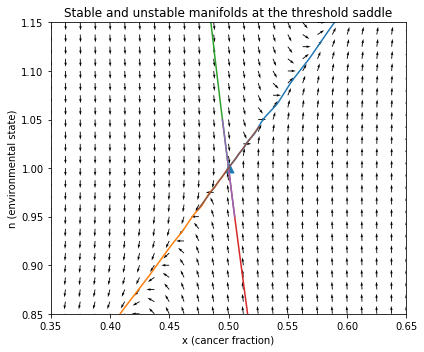

In [289]:
# -----------------------------
# Plot stable and unstable manifolds around the saddle
# -----------------------------

delta = 1e-3  # small displacement from the saddle
T = 60.0      # integration horizon

plt.figure(figsize=(6, 5))

# Vector field background (small window)
dx_win = 0.15
dn_win = 0.15
x_min = max(0.0, x_saddle - dx_win)
x_max = min(1.0, x_saddle + dx_win)
n_min = max(0.0, n_saddle - dn_win)
n_max = n_saddle + dn_win

x_vals = np.linspace(x_min, x_max, 25)
n_vals = np.linspace(n_min, n_max, 25)
X, N = np.meshgrid(x_vals, n_vals)
U, V = f(0.0, (X, N))

speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed
plt.quiver(X, N, U_norm, V_norm, angles="xy")

# Plot saddle
plt.scatter([x_saddle], [n_saddle], marker="^", s=80, label="Saddle")

# Unstable manifold: integrate forward from ±delta * v_unstable
for sign in [+1, -1]:
    y0 = np.array([x_saddle, n_saddle]) + sign * delta * v_unstable
    t_eval = np.linspace(0.0, T, 1000)
    sol = solve_ivp(f, (0.0, T), y0, t_eval=t_eval, dense_output=False)
    plt.plot(sol.y[0], sol.y[1])  # unstable manifold branches

# Stable manifold: integrate backward from ±delta * v_stable
for sign in [+1, -1]:
    y0 = np.array([x_saddle, n_saddle]) + sign * delta * v_stable
    t_eval = np.linspace(0.0, -T, 1000)
    sol = solve_ivp(f, (0.0, -T), y0, t_eval=t_eval, dense_output=False)
    plt.plot(sol.y[0], sol.y[1])  # stable manifold branches

# Also draw the eigenvector directions as straight lines (linear approx)
# just to connect to the Jacobian
line_len = 0.05
for v, label in [(v_stable, "stable dir"), (v_unstable, "unstable dir")]:
    xs = np.array([x_saddle - line_len * v[0], x_saddle + line_len * v[0]])
    ns = np.array([n_saddle - line_len * v[1], n_saddle + line_len * v[1]])
    plt.plot(xs, ns)

plt.xlabel("x (cancer fraction)")
plt.ylabel("n (environmental state)")
plt.xlim(x_min, x_max)
plt.ylim(n_min, n_max)
plt.title("Stable and unstable manifolds at the threshold saddle")
plt.tight_layout()
plt.show()

How to read this figure

Around the saddle you’ll see a cross-like structure:

- Two branches (the unstable manifold) emanating outward following the unstable eigenvector.

- Two branches (the stable manifold) coming into the saddle when integrating forward in time (we traced them backward numerically).

The straight short segments drawn from the eigenvectors show the linear approximation at the saddle:

- Near the saddle, the manifolds are tangent to these eigenvectors (this is the statement that “the stable/unstable manifolds are tangent to the corresponding eigenspaces of J at the equilibrium”).

This is the pure dynamical-systems picture:

- The basin boundary is the stable manifold (the branches of the stable manifold separate trajectories going to healthy vs cancer).
- The unstable manifold is the “crest” that trajectories slide off to reach one attractor or the other.

### Basin boundary for $\rho > k$

The basin boundary is the stable manifold of that saddle. Numerically we:

- Compute the Jacobian at the saddle and its eigenvalues/eigenvectors.
- Identify the stable eigenvector (the one for the negative eigenvalue).
- Start just off the saddle along that direction and integrate backwards in time. This traces out the stable manifold in both directions away from the saddle.
- Overlay this curve on a basin-colour plot and on the vector field.

In [311]:
# ---------------------------
# Parameters (hostile, ρ > k)
# ---------------------------
alpha = 1.0
beta  = 1.0
k     = 1.0
epsilon = 2.0   # choose > mu * k
mu      = 1.0

rho = epsilon / mu
print("rho =", rho, "(> k, bistable regime)")

def make_rhs_hostile(alpha, beta, epsilon, mu, k):
    def dxdt(t, x, n):
        return x * (1 - x) * (n - k) / (n + k) * (beta * x + alpha * (1 - x))
    
    def dndt(t, x, n):
        return epsilon * x - mu * n
    
    def f(t, y):
        x, n = y
        return [dxdt(t, x, n), dndt(t, x, n)]
    
    return f

f = make_rhs_hostile(alpha, beta, epsilon, mu, k)

# ---------------------------
# Jacobian for hostile system
# ---------------------------
def jac_hostile(x, n, alpha, beta, epsilon, mu, k):
    # xdot = x(1-x)*((n-k)/(n+k)) * (β x + α(1-x))
    if n + k == 0:
        return np.array([[0.0, 0.0],
                         [0.0, -mu]])
    
    g = (n - k) / (n + k)
    h = beta * x + alpha * (1 - x)   # = α + (β-α)x

    # ∂ẋ/∂x = g * [ (1-2x)*h + x(1-x)*(β-α) ]
    dxdx = g * ((1 - 2*x)*h + x*(1 - x)*(beta - alpha))

    # ∂ẋ/∂n = x(1-x)*h * ∂g/∂n, with ∂g/∂n = 2k/(n+k)^2
    dgdn = 2 * k / (n + k)**2
    dxdn = x * (1 - x) * h * dgdn

    # ṅ = ε x - μ n
    dndx = epsilon
    dndn = -mu

    return np.array([[dxdx, dxdn],
                     [dndx, dndn]])

# ---------------------------
# Equilibria
# ---------------------------
x_healthy, n_healthy = 0.0, 0.0
x_cancer,  n_cancer  = 1.0, rho
x_saddle   = mu * k / epsilon  # = k / rho
n_saddle   = k

print("Saddle at:", x_saddle, n_saddle)

# ---------------------------
# Stable manifold from saddle
# ---------------------------
J = jac_hostile(x_saddle, n_saddle, alpha, beta, epsilon, mu, k)
eigvals, eigvecs = np.linalg.eig(J)

# stable eigenvector = eigenvector corresponding to negative eigenvalue
idx_stable = np.argmin(eigvals.real)  # smallest real part
v_stable = eigvecs[:, idx_stable].real
v_stable /= np.linalg.norm(v_stable)

# We start slightly off the saddle along ± stable direction
delta = 1e-3
y0_plus  = np.array([x_saddle, n_saddle]) + delta * v_stable
y0_minus = np.array([x_saddle, n_saddle]) - delta * v_stable

# Integrate backwards in time to trace the stable manifold
t_span = (0.0, -100.0)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

sol_plus  = solve_ivp(f, t_span, y0_plus,  t_eval=t_eval, rtol=1e-8, atol=1e-10)
sol_minus = solve_ivp(f, t_span, y0_minus, t_eval=t_eval, rtol=1e-8, atol=1e-10)

# ---------------------------
# Basin plot (classification)
# ---------------------------
x_min, x_max = 0.0, 1.0
n_min, n_max = 0.0, max(rho * 1.2, k * 1.5)

Nx, Nn = 100, 100
xs = np.linspace(x_min, x_max, Nx)
ns = np.linspace(n_min, n_max, Nn)

basin = np.zeros((Nn, Nx), dtype=int)  # 0 = healthy, 1 = cancer

T_final = 80.0
for i, n0 in enumerate(ns):
    for j, x0 in enumerate(xs):
        sol = solve_ivp(f, (0.0, T_final), [x0, n0],
                        t_eval=[T_final], rtol=1e-6, atol=1e-9)
        xT, nT = sol.y[0, -1], sol.y[1, -1]
        d_healthy = np.hypot(xT - x_healthy, nT - n_healthy)
        d_cancer  = np.hypot(xT - x_cancer,  nT - n_cancer)
        basin[i, j] = 0 if d_healthy < d_cancer else 1

# ---------------------------
# Vector field on same domain
# ---------------------------
x_grid = np.linspace(x_min, x_max, 25)
n_grid = np.linspace(n_min, n_max, 25)
X, N = np.meshgrid(x_grid, n_grid)

U = np.zeros_like(X)
V = np.zeros_like(N)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        dx, dn = f(0.0, (X[i, j], N[i, j]))
        U[i, j] = dx
        V[i, j] = dn

speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

rho = 2.0 (> k, bistable regime)
Saddle at: 0.5 1.0


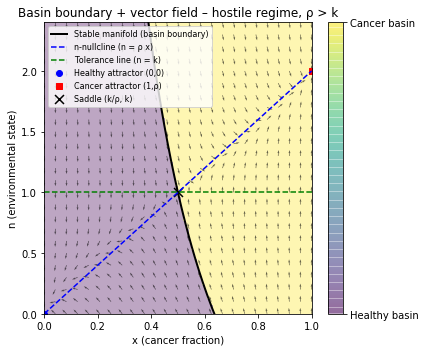

In [310]:
# ---------------------------
# Plot: basin + vector field + stable manifold + nullclines + equilibria
# ---------------------------
plt.figure(figsize=(6, 5))

# basins as background
plt.imshow(
    basin,
    origin='lower',
    extent=[x_min, x_max, n_min, n_max],
    aspect='auto',
    alpha=0.35,
)

cbar = plt.colorbar(ticks=[0, 1])
cbar.ax.set_yticklabels(['Healthy basin', 'Cancer basin'])

# vector field on top
plt.quiver(X, N, U_norm, V_norm, angles='xy', alpha=0.6)

# stable manifold (both branches)
plt.plot(sol_plus.y[0],  sol_plus.y[1],  'k-', lw=2, label='Stable manifold (basin boundary)')
plt.plot(sol_minus.y[0], sol_minus.y[1], 'k-', lw=2)

# nullclines
x_nc = np.linspace(0.0, 1.0, 200)
n_nc = rho * x_nc
plt.plot(x_nc, n_nc, 'b--', label='n-nullcline (n = ρ x)')
plt.axhline(k, color='g', linestyle='--', label='Tolerance line (n = k)')

# equilibria
plt.scatter([x_healthy], [n_healthy], c='blue', marker='o', label='Healthy attractor (0,0)')
plt.scatter([x_cancer],  [n_cancer],  c='red',  marker='s', label='Cancer attractor (1,ρ)')
plt.scatter([x_saddle],  [n_saddle],  c='black', marker='x', s=80, label='Saddle (k/ρ, k)')

plt.xlim(x_min, x_max)
plt.ylim(n_min, n_max)
plt.xlabel("x (cancer fraction)")
plt.ylabel("n (environmental state)")
plt.title("Basin boundary + vector field – hostile regime, ρ > k")
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

Background colours (basin plot)
For each initial condition on a grid, we integrate forward and colour it:
- blue = ends up at (0,0),
- red = ends up at (1,ρ).
This shows the two basins of attraction.

Black curve (stable manifold)
The black curve is the stable manifold of the saddle at $(k/\rho,k)$.
It is the exact basin boundary: it separates the blue and red regions.
- Points on one side flow to healthy,
- points on the other side flow to cancer,
- points exactly on the curve flow into the saddle.

Dashed lines (nullclines)
- $n=\rho x$: environmental nullcline.
- $n=k$: environmental tolerance line (where payoffs flip sign).
Their intersection is exactly the saddle.

This is the figure that makes the dynamical picture and the “threshold” idea immediately visible to both.

### Time series across the threshold

Very few values, need more

epsilons: [0.5, 1.0, 1.5]
labels: ['$\\rho = 0.50$', '$\\rho = 1.00$', '$\\rho = 1.50$']


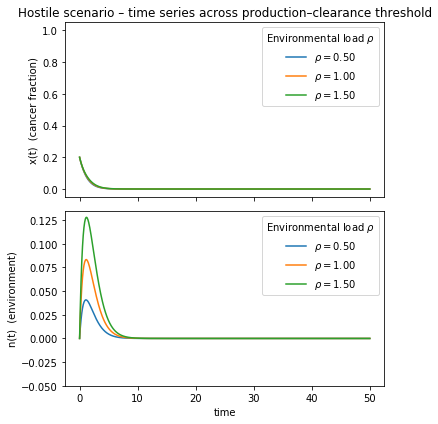

In [176]:
# -----------------------------
# Parameters for hostile scenario
# -----------------------------
alpha = 1.0   # > 0
beta  = 1.0   # > 0
k     = 1.0   # tolerance

mu = 1.0      # clearance rate

# Choose three epsilons so that rho = epsilon/mu gives:
#   rho < k, rho = k, rho > k
epsilons = [
    0.5 * mu * k,   # rho = 0.5 k   (sub-threshold)
    1.0 * mu * k,   # rho = 1.0 k   (threshold)
    1.5 * mu * k    # rho = 1.5 k   (super-threshold)
]

labels = []
for eps in epsilons:
    rho = eps / mu
    labels.append(r"$\rho = {:.2f}$".format(rho))

print("epsilons:", epsilons)
print("labels:", labels)

# -----------------------------
# Dynamics (same hostile model)
# -----------------------------
def make_rhs_hostile(alpha, beta, epsilon, mu, k):
    def dxdt(t, x, n):
        # x*(1-x)*((n-k)/(n+k))*(beta*x + alpha*(1-x))
        # n + k > 0 in our biological region (n >= 0, k > 0)
        return x * (1.0 - x) * (n - k) / (n + k) * (beta * x + alpha * (1.0 - x))
    
    def dndt(t, x, n):
        return epsilon * x - mu * n
    
    def f(t, y):
        x, n = y
        return [dxdt(t, x, n), dndt(t, x, n)]
    
    return f

# -----------------------------
# Time interval and initial condition
# -----------------------------
t_span = (0.0, 50.0)
t_eval = np.linspace(t_span[0], t_span[1], 800)

# A single initial condition for all three regimes
x0 = 0.2
n0 = 0.0

# -----------------------------
# Solve and plot time series
# -----------------------------
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6))

for epsilon, lab in zip(epsilons, labels):
    f = make_rhs_hostile(alpha, beta, epsilon, mu, k)
    sol = solve_ivp(f, t_span, [x0, n0], t_eval=t_eval, dense_output=False)
    
    t = sol.t
    x = sol.y[0]
    n = sol.y[1]
    
    axes[0].plot(t, x, label=lab)
    axes[1].plot(t, n, label=lab)

# -----------------------------
# Formatting
# -----------------------------
axes[0].set_ylabel("x(t)  (cancer fraction)")
axes[1].set_ylabel("n(t)  (environment)")
axes[1].set_xlabel("time")

axes[0].set_title("Hostile scenario – time series across production–clearance threshold")

axes[0].set_ylim(-0.05, 1.05)
axes[1].set_ylim(bottom=-0.05)

axes[0].legend(title=r"Environmental load $\rho$")
axes[1].legend(title=r"Environmental load $\rho$")

plt.tight_layout()
plt.show()


### Stable environment for coexistence

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      \alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      \alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way, the dynamics of the cancer cells population is,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \beta\left( \frac{n-k}{n+k}\right) x_2 + \alpha(1-x_2)\right)
\end{equation}

In [30]:
def x_full(x, alpha, beta, n, k, dt):
    return (x*(1-x)*(beta*((n-k)/(n+k))*x+alpha*(1-x)))*dt + x

In [21]:
def Mh_func(alpha,beta):
    return np.array([[0, beta],
                     [alpha, 0]])

$\alpha=0.1, \beta=0.9, \epsilon=0.04, \mu=0.02, k=2$

#### Versión full

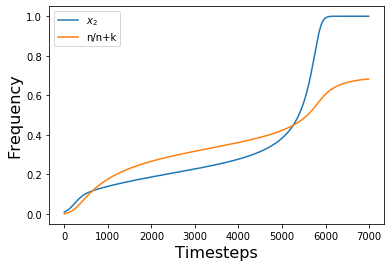

In [31]:
alpha = 0.1
beta = 0.9
eps = 0.09
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 700.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    #M = Mn(f(k,ns[-1]), Mh,Ms)
    #alphan = M[1,0]
    #betan = M[0,1]
    xs.append(x_full(xs[-1],alpha,beta,ns[-1],k,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

#### Versión modular

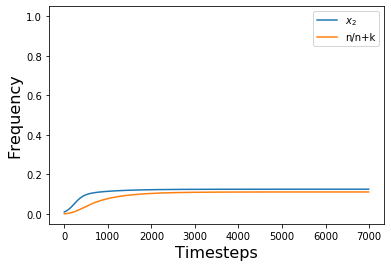

In [32]:
alpha = 0.1
beta = 0.9
eps = 0.04
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 700.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

$\alpha=0.1, \beta=0.9, \epsilon=0.09, \mu=0.02, k=2$

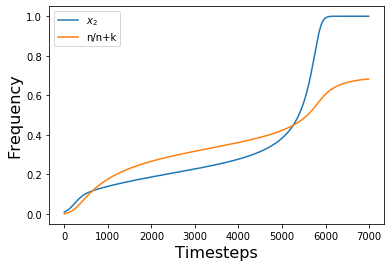

In [33]:
alpha = 0.1
beta = 0.9
eps = 0.09
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 700.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

### Full algebraic version

In [372]:
def x_full(x, alpha, beta, n, k, dt):
    return (x*(1-x)*(beta*((n-k)/(n+k))*x+alpha*(1-x)))*dt + x

def n(n,x,eps,mu,dt):
    return (eps*x - mu*n)*dt + n

### Taylor

Taylor approximation for $\rho < k$ and close to $k$,
\begin{equation}
    x_2^* \approx x_2^*(k) + \frac{d x}{d \rho}_{\rho = k}(\rho - k)
\end{equation}
\begin{equation}
    x_2^* \approx 1 - \frac{\beta}{k(2\alpha - \beta)}(k-\rho)
\end{equation}

In [425]:
def x2_taylor(alpha, beta, k, rho):
    return (1 - beta / (k*(2*alpha-beta))*(k-rho))

### Internal branch

\begin{equation}
    \begin{aligned}
        x_2^*(\rho) &= \frac{2\alpha k}{\alpha (k-\rho)+\beta k +\sqrt{(\alpha(k-\rho)+\beta k)^2+4\rho(\alpha-\beta)\alpha k}}
    \end{aligned}
\end{equation}

In [426]:
def x_int(alpha, beta, k, rho):
    return 2*alpha*k / (alpha*(k-rho)+beta*k + np.sqrt((alpha*(k-rho)+beta*k)**2+4*rho*(alpha-beta)*alpha*k))

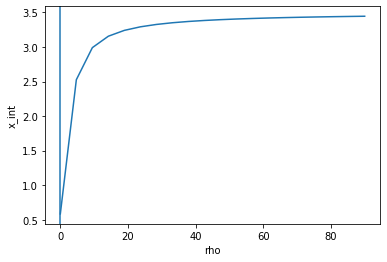

In [586]:
alpha = 0.7#0.1
beta = 0.5#0.9
epss = np.round(np.linspace(0.001, 0.9, 16),3)
mu = 0.01
#k = 4.5#2.3 #2.2 y 2.3 pasa el cambio
k = 1
rhos = epss / mu

#plt.plot(rhos, x_int(alpha, beta, k, rhos))
plt.plot(np.linspace(0,90,20), x_int(alpha, beta, k, np.linspace(0,90,20)))
plt.xlabel('rho')
plt.ylabel('x_int')
plt.axvline(mu*k)
plt.show()

In [579]:
np.linspace(0,6,20)

array([0.        , 0.31578947, 0.63157895, 0.94736842, 1.26315789,
       1.57894737, 1.89473684, 2.21052632, 2.52631579, 2.84210526,
       3.15789474, 3.47368421, 3.78947368, 4.10526316, 4.42105263,
       4.73684211, 5.05263158, 5.36842105, 5.68421053, 6.        ])

In [585]:
rhos

array([ 0.1,  6.1, 12.1, 18.1, 24.1, 30.1, 36.1, 42.1, 48. , 54. , 60. ,
       66. , 72. , 78. , 84. , 90. ])

In [587]:
x_int(alpha, beta, k, rhos)[-1]

3.444623070437686

In [588]:
# limit
alpha / (alpha - beta)

3.5000000000000004

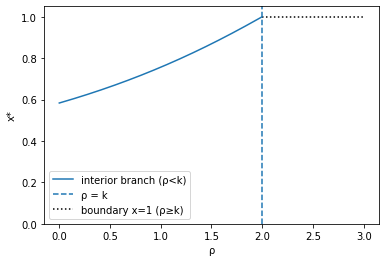

In [591]:
k = 2
def x_int(alpha, beta, k, rho):
    A = rho*(alpha-beta)
    B = alpha*(k-rho) + beta*k
    C = -alpha*k
    return 2*alpha*k / (B + np.sqrt(B**2 + 4*rho*(alpha-beta)*alpha*k))  # same as your formula

rhos = np.linspace(0, 1.5*k, 400)  # sweep up to 1.5*k
x_vals = x_int(alpha, beta, k, rhos)
x_vals = np.where(rhos < k, x_vals, np.nan)  # only show interior where it exists

plt.plot(rhos, x_vals, label='interior branch (ρ<k)')
plt.axvline(k, ls='--', label='ρ = k')
plt.hlines(1, k, rhos.max(), linestyles=':', label='boundary x=1 (ρ≥k)')
plt.ylim(0, 1.05)   # interior is in (0,1)
plt.xlabel('ρ'); plt.ylabel('x*'); plt.legend(); plt.show()


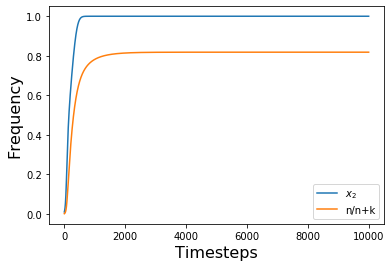

In [486]:
alpha = 0.5#0.1
beta = 0.5#0.9
eps = 0.09 #0.09
mu = 0.02
#k = 4.5#2.3 #2.2 y 2.3 pasa el cambio
k = 1

dt = 0.1
x20 = 0.01
n0 = 0.001

#Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 1000.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    xs.append(x_full(xs[-1],alpha,beta,ns[-1],k,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

In [465]:
k, eps / mu

(5.0, 4.5)

In [466]:
x2_taylor(alpha, beta, k, rho)

0.9

In [467]:
x_int(alpha, beta, k, rho)

0.9090909090909091

In [468]:
xs[-1], ns[-1], rho*xs[-1]

(0.9090909013576103, 4.090909028556758, 4.090909056109246)

In [469]:
alpha / (alpha + beta)

0.5

In [470]:
k / (2*k - rho)

0.9090909090909091

/Users/guillermo/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


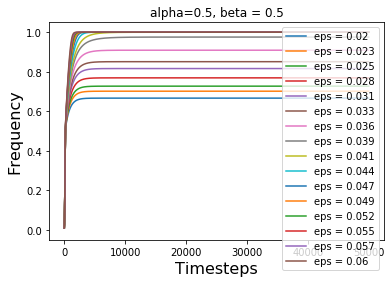

In [558]:
alpha = 0.5#0.1
beta = 0.5#0.9
epss = np.round(np.linspace(0.02, 0.06, 16),3)
mu = 0.02
#k = 4.5#2.3 #2.2 y 2.3 pasa el cambio
k = 2

dt = 0.1

xss = []
xints = []
for eps in epss:
    x20 = 0.01
    n0 = 0.001
    xs = [x20]
    ns = [n0]
    for t in np.arange(1, 5000.0001, dt):
        ns.append(n(ns[-1],xs[-1],eps,mu,dt))
        xs.append(x_full(xs[-1],alpha,beta,ns[-1],k,dt))
    xss.append(xs[-1])
    xints.append(x_int(alpha, beta, k, eps/mu))
    plt.title(f'alpha={alpha}, beta = {beta}')
    plt.plot(xs, label=f'eps = {eps}')
    #plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
    plt.legend()
    plt.xlabel('Timesteps',fontsize=16)
    plt.ylabel('Frequency',fontsize=16)
    plt.ylim(-0.05,1.05)
plt.show()

In [559]:
k*mu

0.04

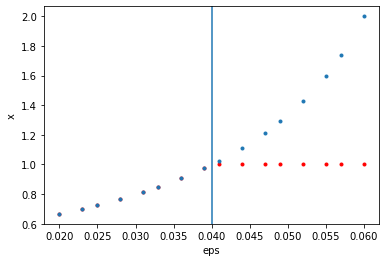

In [562]:
plt.plot(epss,xss, '.r')
plt.plot(epss,xints, '.')
plt.axvline(k*mu)
plt.ylabel('x')
plt.xlabel('eps')
plt.show()

In [574]:
np.array(xss)# - np.array(xints)

array([0.66666667, 0.70175439, 0.72727273, 0.76923077, 0.81632653,
       0.85106383, 0.90909091, 0.97560976, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

In [521]:
np.linspace(0.01, 0.06, 6)

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06])

/Users/guillermo/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


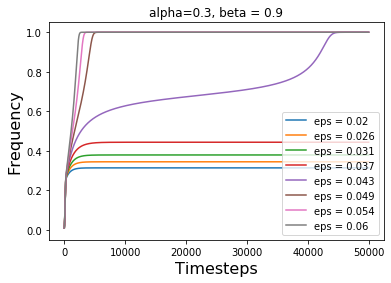

In [527]:
alpha = 0.3#0.1
beta = 0.9#0.9
epss = np.round(np.linspace(0.02, 0.06, 8),3)
mu = 0.02
#k = 4.5#2.3 #2.2 y 2.3 pasa el cambio
k = 2

dt = 0.1


for eps in epss:
    x20 = 0.01
    n0 = 0.001
    xs = [x20]
    ns = [n0]
    for t in np.arange(1, 5000.0001, dt):
        ns.append(n(ns[-1],xs[-1],eps,mu,dt))
        xs.append(x_full(xs[-1],alpha,beta,ns[-1],k,dt))
    plt.title(f'alpha={alpha}, beta = {beta}')
    plt.plot(xs, label=f'eps = {eps}')
    #plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
    plt.legend()
    plt.xlabel('Timesteps',fontsize=16)
    plt.ylabel('Frequency',fontsize=16)
    plt.ylim(-0.05,1.05)
plt.show()

In [520]:
# threshold
k*mu

0.04

### Summary coexistence section

In [ ]:
# ============================================================
# Replicator + Environmental Feedback — Figures (1)–(11)
# ============================================================
# This script generates a full figure set to present the
# analytics and intuition of the 2-strategy replicator with a
# Hill-like environmental feedback (via n, thresholded by k).
#
# Biology summary:
# - x in [0,1] is the cancer strategy frequency.
# - n is a toxin / environmental state, produced ~ eps*x, cleared ~ mu*n.
# - Control parameter: rho = eps/mu, normalized as rho_hat = rho/k.
# - Interior coexistence exists iff rho_hat < 1; at rho_hat = 1, the interior
#   collides with the boundary x=1; for rho_hat > 1, only x=1 remains.
#
# Libraries: numpy, matplotlib (no seaborn; one chart per figure)
# ============================================================

In [ ]:
# -----------------------------
# Core algebra (interior root)
# -----------------------------

In [794]:
def x_star_interior(alpha, beta, k, rho):
    """
    Algebraic interior root using the robust 'conjugate' quadratic form:
      x*(rho) = 2C / ( -B - sqrt(B^2 - 4AC) )
      where A = rho*(alpha - beta),
            B = alpha*(k - rho) + beta*k,
            C = -alpha*k

    Notes:
    - This returns the algebraic value for any rho.
    - The INTERIOR equilibrium is only *feasible* for rho < k (i.e., rho_hat < 1).
      Always mask your plot there to avoid the misleading continuation beyond 1.
    - We clamp the sqrt argument to >= 0 to avoid tiny negative roundoff.
    """
    A = rho * (alpha - beta)
    B = alpha * (k - rho) + beta * k
    C = -alpha * k
    inside = B**2 - 4.0 * A * C
    inside = np.maximum(inside, 0.0)
    return (2.0 * C) / (-B - np.sqrt(inside))

In [795]:
def x_star_linear_case(alpha, beta, k, rho):
    """
    Special linear case when alpha == beta:
      B x + C = 0 => x* = -C / B = k / (2k - rho)
    Valid as an algebraic expression whenever B != 0.
    Feasibility of interior still requires rho < k for x* in (0,1).
    """
    return k / (2.0 * k - rho)

In [796]:
def x_star(alpha, beta, k, rho, tol=1e-12):
    """
    Vectorized wrapper selecting the proper algebraic branch element-wise:
      - where |alpha - beta| < tol  -> linear case x* = k/(2k - rho)
      - else                         -> conjugate quadratic root

    alpha, beta, rho can be scalars or arrays (broadcasting supported).
    Returns an array broadcast to the common shape.
    """
    alpha = np.asarray(alpha, dtype=float)
    beta  = np.asarray(beta,  dtype=float)
    rho   = np.asarray(rho,   dtype=float)

    alpha_b, beta_b, rho_b = np.broadcast_arrays(alpha, beta, rho)
    out = np.empty_like(rho_b, dtype=float)

    mask_linear = np.isclose(alpha_b - beta_b, 0.0, atol=tol)
    mask_quad   = ~mask_linear

    if np.any(mask_linear):
        out[mask_linear] = x_star_linear_case(alpha_b[mask_linear],
                                              beta_b[mask_linear],
                                              k, rho_b[mask_linear])
    if np.any(mask_quad):
        out[mask_quad] = x_star_interior(alpha_b[mask_quad],
                                         beta_b[mask_quad],
                                         k, rho_b[mask_quad])
    return out

In [797]:
def interior_exists(k, rho):
    """
    Existence of an interior equilibrium in (0,1) follows from endpoint signs:
      P(0) = -alpha*k < 0      (for alpha>0)
      P(1) = beta*(k - rho)
    => interior root in (0,1) iff rho < k.
    This condition is independent of alpha,beta beyond positivity.
    """
    return rho < k

In [798]:
def taylor_near_threshold(alpha, beta, k, rho):
    """
    1st-order Taylor approximation near the collision (from the left, rho -> k^-):
      x*(rho) ≈ 1 - [ beta / (k*(2*alpha - beta)) ] * (k - rho)

    Use only very close to rho = k and preferably when 2*alpha > beta
    (positive slope) — otherwise the linear term is not informative.
    """
    denom = k * (2.0 * alpha - beta)
    return 1.0 - (beta / denom) * (k - rho)

In [799]:
def x_nullcline_curve(alpha, beta, k, x):
    """
    Nontrivial x-nullcline q(x,n)=0 rearranged to n(x):
      n = k * [- alpha(1-x) + beta x] / [alpha(1-x) + beta x]
    (plus the vertical nullclines at x=0 and x=1 from the x(1-x) factor).
    """
    num = k * (- alpha * (1.0 - x) + beta * x)
    den = (alpha * (1.0 - x) + beta * x)
    return num / den

In [800]:
# -----------------------------
# Vector field + simulator
# -----------------------------

In [801]:
def f_x(x, n, alpha, beta, k):
    """
    Replicator RHS:
      dot{x} = x(1-x) [ alpha(1-x) + beta * h * x ],
      with h = (n - k)/(n + k) in (-1,1).
    Intuition:
      - alpha(1-x): benefit of cancer vs healthy under healthy-like environment.
      - beta*h*x: feedback shift once n exceeds k (environment turns cancer-favoring).
    """
    h = (n - k) / (n + k)
    return x * (1.0 - x) * (alpha * (1.0 - x) + beta * h * x)

In [802]:
def f_n(n, x, eps, mu):
    """
    Environmental toxin dynamics:
      dot{n} = eps * x - mu * n
    Steady state (for fixed x): n* = (eps/mu) * x = rho * x.
    """
    return eps * x - mu * n

In [803]:
def simulate(alpha, beta, eps, mu, k, x0=0.01, n0=0.0, T=200.0, dt=0.01):
    """
    Explicit Euler integrator for the 2D system (x(t), n(t)).
    Keeps x in [0,1] and n >= 0 by clipping (biological domain).
    """
    steps = int(T / dt)
    xs = np.empty(steps + 1); ns = np.empty(steps + 1); ts = np.empty(steps + 1)
    xs[0] = x0; ns[0] = n0; ts[0] = 0.0
    for i in range(steps):
        x = xs[i]; n = ns[i]
        #xs[i+1] = np.clip(x + dt * f_x(x, n, alpha, beta, k), 0.0, 1.0)
        xs[i+1] = x + dt * f_x(x, n, alpha, beta, k)
        #ns[i+1] = max(n + dt * f_n(n, x, eps, mu), 0.0)
        ns[i+1] = n + dt * f_n(n, x, eps, mu)
        ts[i+1] = ts[i] + dt
    return ts, xs, ns

In [845]:
# -----------------------------
# Figure 1 — Bifurcation diagram x*(rho_hat)
# -----------------------------

def make_fig_1(alpha, beta, k):
    """
    Figure 1 — Bifurcation diagram: x*(rho_hat) vs rho_hat = rho/k.
    Interior exists only for rho_hat < 1; collision at rho_hat = 1; boundary x=1 beyond.

    Why: This is the central 'tipping' picture. It shows coexistence giving way to dominance.
    """
    rho_hat = np.linspace(0.0, 1.5, 400)
    rho = rho_hat * k
    x_alg = x_star(alpha, beta, k, rho)
    x_plot = np.where(rho_hat < 1.0, x_alg, np.nan)  # mask beyond threshold

    plt.figure(figsize=(9,6))
    plt.plot(rho_hat, x_plot, label=r'interior branch $(\hat{\rho} < 1)$')
    plt.axvline(1.0, linestyle='--', label=r'$\hat{\rho} = 1$ (collision)')
    plt.hlines(1.0, 1.0, rho_hat.max(), linestyles=':', label=r'boundary $x=1 (\hat{\rho} ≥ 1)$')
    plt.ylim(0, 1.05)
    plt.xlabel(r'$\hat{\rho}=\rho/k$', fontsize=18)
    plt.ylabel(r'$x^*$', fontsize=18)
    plt.title(fr'Bifurcation diagram $\alpha={alpha}, \beta={beta}$', fontsize=18)
    plt.legend(loc='lower left', fontsize=14)
    plt.show()

In [846]:
# Baseline parameters:
k = 1.0                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs

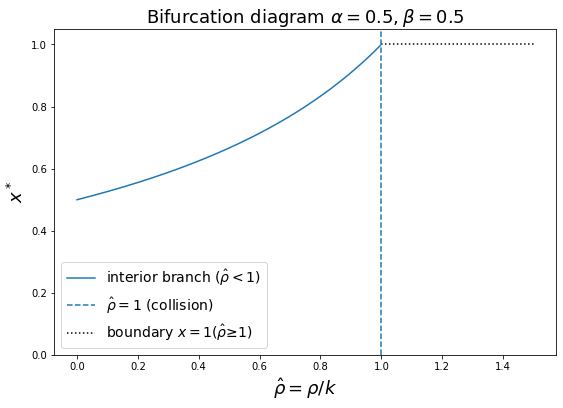

In [847]:
# 1) Bifurcation diagram
make_fig_1(alpha, beta, k)

In [730]:
np.linspace(0,1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

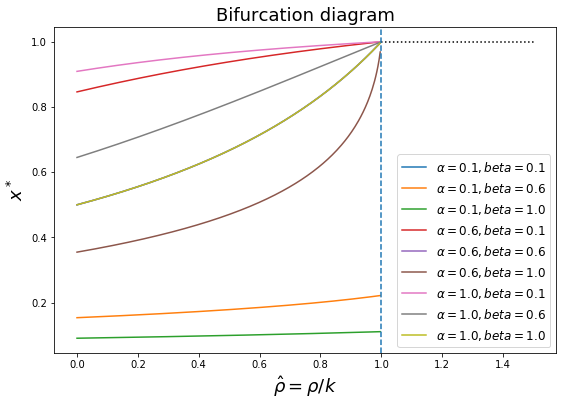

In [848]:
alphas = np.linspace(0.1,1, 3)
betas = np.linspace(0.1,1, 3)
plt.figure(figsize=(9,6))
for alpha in alphas:
    for beta in betas:
        rho_hat = np.linspace(0.0, 1.5, 400)
        rho = rho_hat * k
        x_alg = x_star(alpha, beta, k, rho)
        x_plot = np.where(rho_hat < 1.0, x_alg, np.nan)  # mask beyond threshold

        #plt.figure()
        plt.plot(rho_hat, x_plot, label=fr'$\alpha={alpha:.1f}, beta={beta:.1f}$')
        #plt.axvline(1.0, linestyle='--', label='rho_hat = 1 (collision)')
        #plt.hlines(1.0, 1.0, rho_hat.max(), linestyles=':', label='boundary x=1 (rho_hat ≥ 1)')
        #plt.ylim(0, 1.05)
        plt.xlabel(r'$\hat{\rho}=\rho/k$', fontsize=18)
        plt.ylabel(r'$x^*$', fontsize=18)
        plt.title('Bifurcation diagram', fontsize=18)
        plt.legend(loc='lower right', fontsize=12)

plt.axvline(1.0, linestyle='--', label='rho_hat = 1 (collision)')
plt.hlines(1.0, 1.0, rho_hat.max(), linestyles=':', label='boundary x=1 (rho_hat ≥ 1)')
plt.show()

In [685]:
# Baseline parameters:
k = 1.0                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs

In [857]:
# -----------------------------
# Figures 2 & 3 — Nullclines
# -----------------------------

def make_fig_2(alpha, beta, k, rho_hat=0.7):
    """
    Figure 2 — Nullclines snapshot for rho_hat < 1 (interior exists).
    """
    rho = rho_hat * k
    xgrid = np.linspace(1e-6, 1.0-1e-6, 1000)
    n_curve = x_nullcline_curve(alpha, beta, k, xgrid)
    n_line  = rho * xgrid

    # Vertical asymptote
    x_asym = alpha / (alpha + beta)

    plt.figure(figsize=(8,6))
    plt.plot(xgrid, n_curve, label='x-nullcline (q(x,n)=0)')
    plt.plot(xgrid, n_line,  label=r'$n$-nullcline: $n=\rho x$')
    if 0.0 < x_asym < 1.0:
        plt.axvline(x_asym, ls=':', label=r'asymptote $x=\alpha/(\alpha+\beta)$')
    plt.xlabel('x', fontsize=18); plt.ylabel('n', fontsize=18)
    plt.ylim(0, None)  # enforce n ≥ 0
    plt.title(f'Nullclines (coexistence): $\\hat{{\\rho}}={rho_hat:.2f}<1$', fontsize=18)
    plt.legend(fontsize=12)
    plt.show()

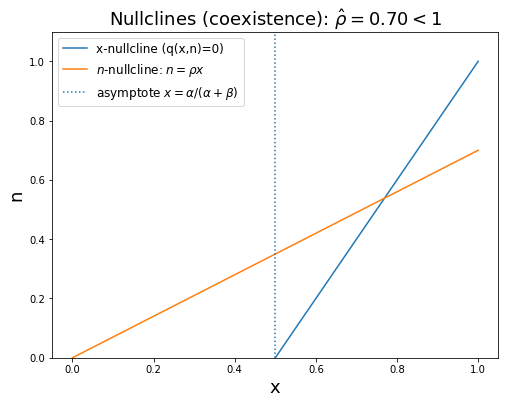

In [858]:
# 2) Nullclines: coexistence snapshot (rho_hat < 1)
make_fig_2(alpha, beta, k, rho_hat=0.7)

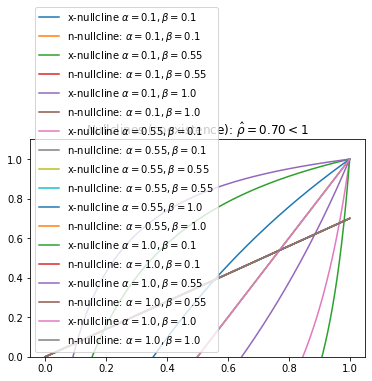

In [734]:
rho_hat=0.7
alphas = np.linspace(0.1,1, 3)
betas = np.linspace(0.1,1, 3)
for alpha in alphas:
    for beta in betas:
        rho = rho_hat * k
        xgrid = np.linspace(1e-6, 1.0-1e-6, 1000)
        n_curve = x_nullcline_curve(alpha, beta, k, xgrid)
        n_line  = rho * xgrid

        # Vertical asymptote
        #x_asym = alpha / (alpha + beta)

        #plt.figure()
        plt.plot(xgrid, n_curve, label=fr'x-nullcline $\alpha={alpha}, \beta={beta}$')
        plt.plot(xgrid, n_line,  label=fr'n-nullcline: $\alpha={alpha}, \beta={beta}$')
        """
        if 0.0 < x_asym < 1.0:
            plt.axvline(x_asym, ls=':', label=r'asymptote $x=\alpha/(\alpha+\beta)$')
        plt.xlabel('x'); plt.ylabel('n')
        """
        plt.ylim(0, None)  # enforce n ≥ 0
        plt.title(f'Nullclines (coexistence): $\\hat{{\\rho}}={rho_hat:.2f}<1$')
plt.legend()
plt.show()

In [865]:
def make_fig_3(alpha, beta, k, rho_hat=1.3):
    """
    Figure 3 — Nullclines snapshot for rho_hat > 1 (no interior).
    Shows only the feasible branch n>=0 of the x-nullcline, shades n<0, and
    marks the vertical asymptote at x = alpha/(alpha+beta).
    """
    rho = rho_hat * k
    xgrid = np.linspace(1e-6, 1.0-1e-6, 2000)

    # x-nullcline curve: n(x) = k*(alpha(1-x) - beta x) / (alpha(1-x) + beta x)
    n_curve = x_nullcline_curve(alpha, beta, k, xgrid)

    # Feasible part (biology): n >= 0
    feasible = n_curve >= 0

    # n-nullcline line: n = rho * x
    n_line  = rho * xgrid

    # Vertical asymptote where alpha(1-x) + beta x = 0  ->  x = alpha/(alpha+beta)
    x_asym = alpha / (alpha + beta)

    plt.figure(figsize=(8,6))

    # Shade the infeasible region (n < 0) lightly for context
    plt.fill_between([0, 1], 0, -1, color='0.95')

    # Plot only the feasible branch of the x-nullcline
    plt.plot(xgrid[feasible], n_curve[feasible], label='x-nullcline (feasible n ≥ 0)')

    # Optionally show the infeasible branch as faint dashed
    if np.any(~feasible):
        plt.plot(xgrid[~feasible], n_curve[~feasible], ls='--', alpha=0.4,
                 label='x-nullcline (infeasible n < 0)')

    # Plot n-nullcline (keep mathtext here; it’s correct)
    plt.plot(xgrid, n_line,  label=r'$n$-nullcline: $n=\rho x$')

    # Mark the vertical asymptote (if within [0,1])
    if 0.0 < x_asym < 1.0:
        plt.axvline(x_asym, ls=':', label=r'asymptote $x=\alpha/(\alpha+\beta)$')

    plt.xlabel('x', fontsize=18); plt.ylabel('n', fontsize=18)
    plt.ylim(0, None)  # biological range for n
    plt.title(f'Nullclines (no interior): $\\hat{{\\rho}}={rho_hat:.2f}>1$', fontsize=18)
    plt.legend(loc='upper left', fontsize=12)
    plt.show()

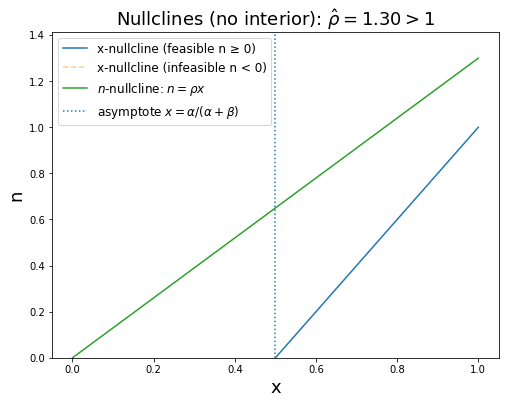

In [866]:
# 3) Nullclines: no-interior snapshot (rho_hat > 1)
make_fig_3(alpha, beta, k, rho_hat=1.3)

In [736]:
# -----------------------------
# Figure 4 — Feasibility map (same as Fig.1, emphasis on masking)
# -----------------------------

def make_fig_4(alpha, beta, k):
    """
    Figure 4 — Feasibility map: interior branch masked for rho_hat >= 1, boundary shown beyond.
    Why: Reader sees at a glance where the coexistence branch is defined and where it is not.
    """
    rho_hat = np.linspace(0.0, 1.5, 400)
    rho = rho_hat * k
    x_alg = x_star(alpha, beta, k, rho)
    x_plot = np.where(rho_hat < 1.0, x_alg, np.nan)

    plt.figure()
    plt.plot(rho_hat, x_plot, label='interior branch (rho_hat < 1)')
    plt.axvline(1.0, linestyle='--', label='rho_hat = 1 (collision)')
    plt.hlines(1.0, 1.0, rho_hat.max(), linestyles=':', label='boundary x=1 (rho_hat ≥ 1)')
    plt.ylim(0, 1.05)
    plt.xlabel(r'$\hat{\rho}$'); plt.ylabel('x')
    plt.title('Feasibility map: interior exists only for $\\hat{\\rho}<1$')
    plt.legend()
    plt.show()

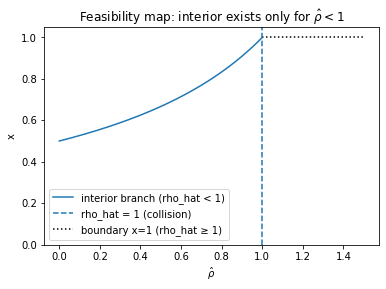

In [737]:
# 4) Feasibility map
make_fig_4(alpha, beta, k)

In [963]:
# -----------------------------
# Figure 5 — x*(rho_hat) vs payoff mix r
# -----------------------------

def make_fig_5(k, rho_hats=(0.2, 0.5, 0.8)):
    """
    Figure 5 — x*(rho_hat) vs r = alpha/(alpha+beta), for several rho_hat < 1.
    Why: Shows how payoff asymmetry (composition r) tilts coexistence composition at fixed load.

    Implementation:
    - Fix total payoff scale s=1 (just sets timescale) and sweep r in (0,1).
    - For each rho_hat<1, compute algebraic x* and mask if needed (though rho_hat is fixed <1 here).
    """
    r = np.linspace(1e-3, 1.0-1e-3, 300)  # avoid endpoints
    plt.figure(figsize=(8,6))
    for rh in rho_hats:
        rho = rh * k
        s = 1.0
        alpha = r * s
        beta  = (1.0 - r) * s
        x_alg = x_star(alpha, beta, k, rho)
        x_plot = np.where(rh < 1.0, x_alg, np.nan)
        plt.plot(r, x_plot, label=fr'$\hat{{\rho}}$={rh:.2f}')
    plt.xlabel(r'$r=\alpha/(\alpha+\beta)$', fontsize=18); plt.ylabel(r'$x^*$', fontsize=18)
    plt.title('Coexistence composition vs payoff mix (only for $\\hat{\\rho}<1$)', fontsize=18)
    plt.legend(loc='lower right', fontsize=12)
    plt.show()

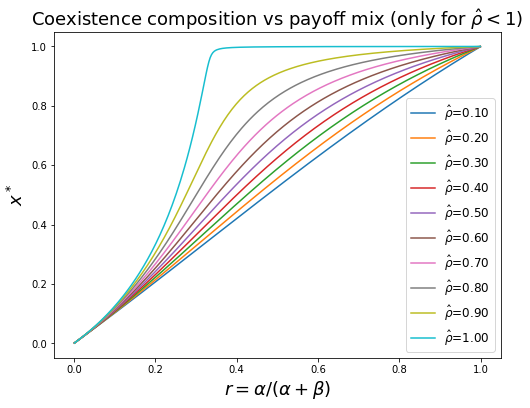

In [964]:
# 5) x*(rho_hat) vs payoff mix r at several rho_hat < 1
make_fig_5(k, rho_hats=np.linspace(0.1,0.999,10))

In [965]:
# -----------------------------
# Figure 6 — No-feedback quadrant map (schematic)
# -----------------------------

def make_fig_6():
    """
    Figure 6 — No-feedback (alpha,beta) schematic quadrant map.
    Why: Provides context — classical 2x2 game outcomes without environmental coupling.
    """
    plt.figure()
    plt.axhline(0.0, linestyle='--', color='black')
    plt.axvline(0.0, linestyle='--', color='black')
    plt.text( 0.5,  0.5, 'Coexistence\n$(\\alpha>0,\\,\\beta>0)$', ha='center', va='center')
    plt.text(-0.5,  0.5, 'Strategy 1 dominates\n$(\\alpha<0,\\,\\beta>0)$', ha='center', va='center')
    plt.text( 0.5, -0.5, 'Strategy 2 dominates\n$(\\alpha>0,\\,\\beta<0)$', ha='center', va='center')
    plt.text(-0.5, -0.5, 'Bistability\n$(\\alpha<0,\\,\\beta<0)$', ha='center', va='center')
    plt.xlim(-1, 1); plt.ylim(-1, 1)
    plt.xlabel('$\\alpha$'); plt.ylabel('$\\beta$')
    plt.title('No-feedback game outcome map (schematic)')
    plt.show()

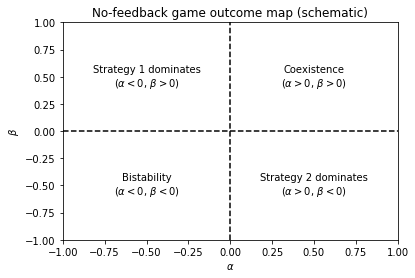

In [750]:
# Baseline parameters:
k = 1.0                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
# 6) No-feedback quadrant map (schematic)
make_fig_6()

In [943]:
# -----------------------------
# Figure 7 — Heatmap of x*(rho_hat, r)
# -----------------------------

def make_fig_7(k, s=1.0, N_r=100, N_rho=120):
    """
    Figure 7 — Heatmap of the interior equilibrium x*(rho_hat, r).
    Why: Compact global view: environmental load (horizontal) vs payoff mix (vertical)
         determining the coexistence composition.

    Implementation:
    - Compute only for rho_hat < 1; mask (NaN) elsewhere.
    """
    rho_hat = np.linspace(0.0, 1.2, N_rho)
    r = np.linspace(1e-3, 1.0-1e-3, N_r)
    XX = np.zeros((N_r, N_rho))
    for i, ri in enumerate(r):
        alpha = ri * s
        beta  = (1.0 - ri) * s
        rho = rho_hat * k
        x_alg = x_star(alpha, beta, k, rho)
        x_alg = np.where(rho_hat < 1.0, x_alg, np.nan)
        XX[i, :] = x_alg

    plt.figure(figsize=(8,6))
    im = plt.imshow(XX, aspect='auto', origin='lower',
                    extent=[rho_hat[0], rho_hat[-1], r[0], r[-1]])
    plt.axvline(1.0, linestyle='--', color='black')
    plt.xlabel(r'$\hat{\rho}$', fontsize=18); plt.ylabel(r'$r=\alpha/(\alpha+\beta)$', fontsize=18)
    plt.title(r'$x^*(\hat{\rho}, r)$ Heatmap', fontsize=18)
    cbar = plt.colorbar(im, label=r'$x^*$')#, labelsize=18)
    cbar.set_label(r'$x^*$', fontsize=18) 
    plt.show()

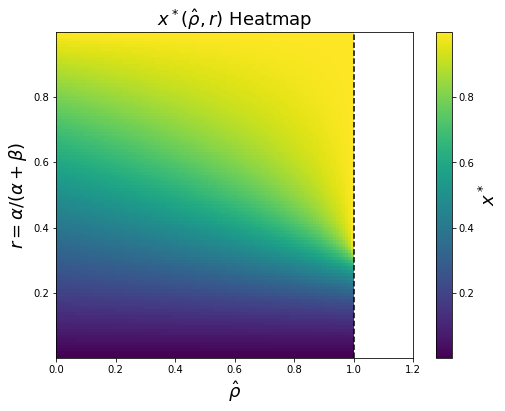

In [944]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
# 7) Heatmap of x*(rho_hat, r)
make_fig_7(k, s=1.0) # invariant to k?

In [894]:
def interior_stability_sign(alpha, beta, k, rho, eps, mu):
    """
    Classify interior equilibrium stability using the full 2x2 Jacobian.
    Returns:
      -1.0 : stable (both eigenvalues have negative real parts)
      +1.0 : unstable (node/focus) or saddle
       np.nan : no interior equilibrium (rho >= k or x* not in (0,1))
    """
    # Feasibility gate: interior exists only if rho < k
    if rho >= k:
        return np.nan

    # Compute interior fixed point x* (use your branch that stays finite as rho->0)
    x = x_star(alpha, beta, k, rho)  # your robust algebraic branch
    if not (0.0 < x < 1.0):
        return np.nan

    n = rho * x
    h = (n - k) / (n + k)                 # feedback factor
    dh_dn = 2.0 * k / (n + k)**2          # derivative of h

    # Shorthands
    g  = beta * h * x + alpha * (1.0 - x) # bracket in dot{x}
    dx = (1.0 - 2.0 * x) * g + x * (1.0 - x) * (beta * h - alpha)
    dn = x**2 * (1.0 - x) * beta * dh_dn

    tr  = dx - mu
    det = (-mu) * dx - eps * dn

    if det < 0.0:
        return 1.0  # saddle (unstable)
    # det >= 0: sign of trace decides
    return -1.0 if tr < 0.0 else 1.0

In [945]:
def make_fig_8(k, eps, mu, s=1.0, N_r=120, N_rho=140):
    rho_hat = np.linspace(0.0, 1.2, N_rho)
    r = np.linspace(1e-3, 1.0-1e-3, N_r)
    SS = np.full((N_r, N_rho), np.nan)
    for i, ri in enumerate(r):
        alpha = ri * s
        beta  = (1.0 - ri) * s
        for j, rh in enumerate(rho_hat):
            rho = rh * k
            SS[i, j] = interior_stability_sign(alpha, beta, k, rho, eps, mu)

    plt.figure(figsize=(8,6))
    im = plt.imshow(SS, aspect='auto', origin='lower',
                    extent=[rho_hat[0], rho_hat[-1], r[0], r[-1]])
    plt.axvline(1.0, linestyle='--', color='black')
    plt.xlabel(r'$\hat{\rho}$', fontsize=18); plt.ylabel(r'$r$', fontsize=18)
    title_txt = (fr'Equilibrium stability, $\epsilon={eps}, \mu={mu}$')
    plt.title(title_txt, fontsize=18)
    cbar = plt.colorbar(im, label='stability sign')
    cbar.set_label('stability sign', fontsize=18) 
    plt.show()

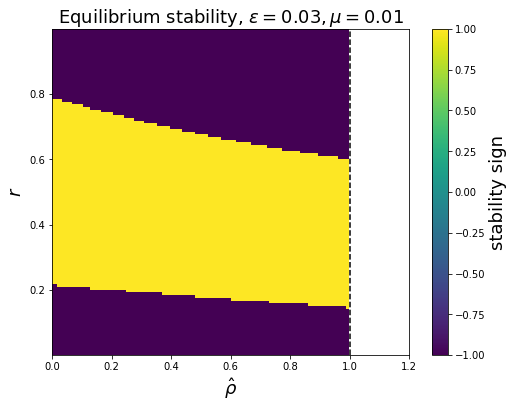

In [946]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
#eps, mu = 0.02, 0.03
eps, mu = 0.03, 0.01
# 8) Heatmap of interior stability
make_fig_8(k, eps, mu, s=1.0)

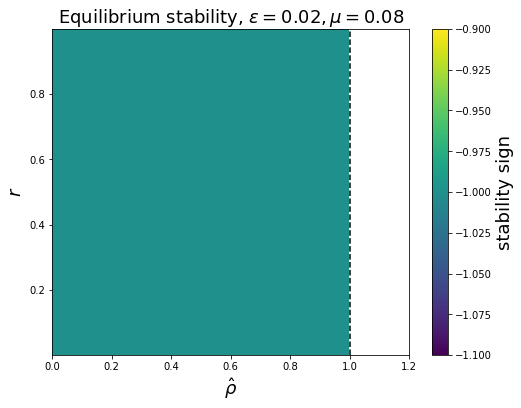

In [947]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
#eps, mu = 0.02, 0.03
eps, mu = 0.02, 0.08
# 8) Heatmap of interior stability
make_fig_8(k, eps, mu, s=1.0)

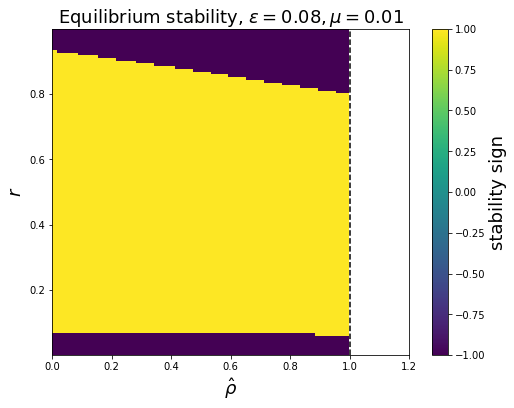

In [948]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
#eps, mu = 0.02, 0.03
eps, mu = 0.08, 0.01
# 8) Heatmap of interior stability
make_fig_8(k, eps, mu, s=1.0)

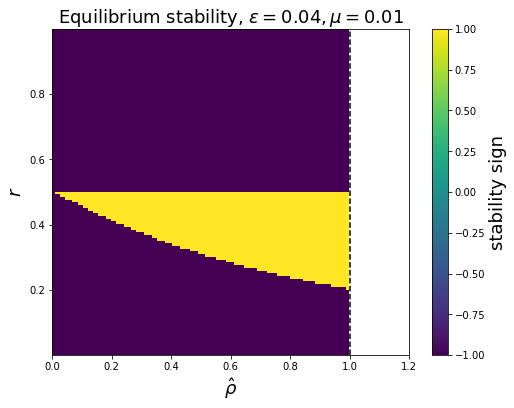

In [949]:
# Baseline parameters:
k = 2.0                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
#eps, mu = 0.02, 0.03
eps, mu = 0.04, 0.01
# 8) Heatmap of interior stability
make_fig_8(k, eps, mu, s=1.0)

In [955]:
# -----------------------------
# Figures 9 & 10 — Time traces
# -----------------------------

def make_fig_9(alpha, beta, k, eps, mu, x0=0.01, n0=0.0):
    """
    Figure 9 — Time traces when rho_hat < 1 (coexistence).
    Why: Dynamics example converging to the interior fixed point (x*, n* = rho x*).
    """
    rho_hat = (eps / mu) / k
    ts, xs, ns = simulate(alpha, beta, eps, mu, k, x0=x0, n0=n0, T=400.0, dt=0.01)
    plt.figure(figsize=(8,6))
    plt.plot(ts, xs, label='x(t)')
    plt.plot(ts, ns, label='n(t)')
    plt.xlabel('time', fontsize=18); plt.ylabel('state', fontsize=18)
    plt.title(f'Dynamics to coexistence ( $\\hat{{\\rho}}={rho_hat:.2f}<1$ )', fontsize=18)
    plt.ylim(-0.05,1.7)
    plt.legend()
    plt.show()

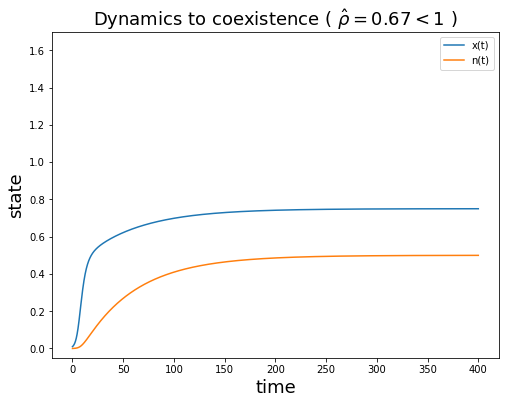

In [956]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
# 9) Time traces — pick eps, mu so rho_hat = (eps/(mu*k)) < 1
eps, mu = 0.02, 0.03    # rho_hat = (0.02/0.03)/1 ≈ 0.666...
make_fig_9(alpha, beta, k, eps, mu)

In [953]:
def make_fig_10(alpha, beta, k, eps, mu, x0=0.01, n0=0.0):
    """
    Figure 10 — Time traces when rho_hat > 1 (dominance).
    Why: Dynamics example converging to boundary x=1.
    """
    rho_hat = (eps / mu) / k
    ts, xs, ns = simulate(alpha, beta, eps, mu, k, x0=x0, n0=n0, T=200.0, dt=0.01)
    plt.figure(figsize=(8,6))
    plt.plot(ts, xs, label='x(t)')
    plt.plot(ts, ns, label='n(t)')
    plt.xlabel('time', fontsize=18); plt.ylabel('state', fontsize=18)
    plt.title(f'Dynamics to dominance ( $\\hat{{\\rho}}={rho_hat:.2f}>1$ )', fontsize=18)
    plt.ylim(-0.05,1.7)
    plt.legend()
    plt.show()

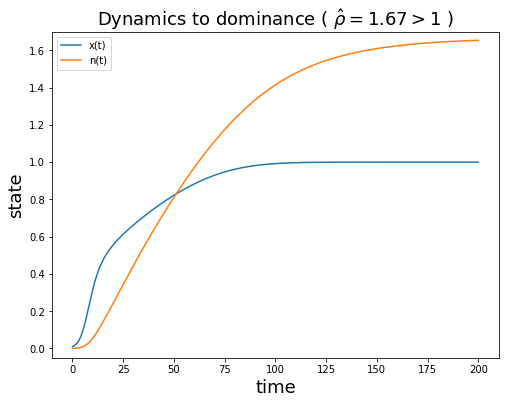

In [954]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
# 10) Time traces — pick eps, mu so rho_hat > 1
eps, mu = 0.05, 0.03    # rho_hat ≈ 1.666...
make_fig_10(alpha, beta, k, eps, mu)

In [772]:
# -----------------------------
# Figure 11 — (epsilon, mu) parameter-plane threshold
# -----------------------------

def make_fig_11(k, mu_range=(0.005, 0.06), eps_range=(0.005, 0.06), N=200):
    """
    Figure 11 — Parameter-plane (epsilon, mu) with threshold line epsilon = mu*k.
    Why: Direct handle for experimentalists — how production (eps) vs recovery (mu)
         must scale to remain under the tipping line (coexistence possible when eps < mu*k).
    """
    mu_vals = np.linspace(mu_range[0], mu_range[1], N)
    # Just plot the threshold line; annotate regions
    plt.figure(figsize=(8,6))
    plt.plot(mu_vals, k * mu_vals, label=r'$\epsilon=\mu k$ (threshold)')
    plt.xlabel(r'$\mu$ (recovery)'); plt.ylabel(r'$\epsilon$ (production)')
    plt.title('Parameter-plane threshold: coexistence if $\\epsilon < \\mu k$')
    # Annotations (plain text to avoid mathtext headaches)
    plt.text(mu_vals[0], k * mu_vals[0] * 0.6, 'coexistence possible\n(ε < μ k)')
    plt.text(mu_vals[-1]*0.6, k * mu_vals[-1]*1.1, 'dominance region\n(ε > μ k)')
    plt.legend()
    plt.show()

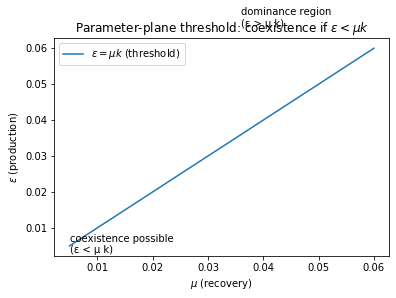

In [773]:
# 11) (epsilon, mu) plane with epsilon = mu*k
make_fig_11(k, mu_range=(0.005, 0.06), eps_range=(0.005, 0.06))

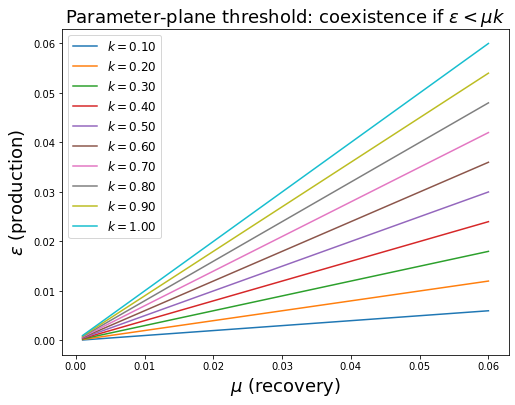

In [929]:
N = 200
mu_range=(0.001, 0.06)
eps_range=(0.001, 0.06)
ks = np.linspace(0.1,1,10)
plt.figure(figsize=(8,6))
for k in ks:
    mu_vals = np.linspace(mu_range[0], mu_range[1], N)
    # Just plot the threshold line; annotate regions
    #plt.figure()
    plt.plot(mu_vals, k * mu_vals, label=fr'$k={k:.2f}$')
plt.xlabel(r'$\mu$ (recovery)',fontsize=18); plt.ylabel(r'$\epsilon$ (production)',fontsize=18)
plt.title('Parameter-plane threshold: coexistence if $\\epsilon < \\mu k$',fontsize=18)
    # Annotations (plain text to avoid mathtext headaches)
    #plt.text(mu_vals[0], k * mu_vals[0] * 0.6, 'coexistence possible\n(ε < μ k)')
    #plt.text(mu_vals[-1]*0.6, k * mu_vals[-1]*1.1, 'dominance region\n(ε > μ k)')
plt.legend(fontsize=12)
plt.show()